How do I update node on my mac?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The easiest way is via `nvm` (Node Version Manager):

```bash
nvm install node --reinstall-packages-from=node
```

If you don't have `nvm`, install it first:

```bash
curl -o- https://raw.githubusercontent.com/nvm-sh/nvm/v0.39.7/install.sh | bash
```

Alternatively, if you installed Node via Homebrew:

```bash
brew upgrade node
```

Or download the latest installer directly from [nodejs.org](https://nodejs.org).

In [ ]:
from fastcore.all import *
from iomeval.readers import find_eval, load_evals, eval_url, get_report_urls
from mistocr.core import read_pgs

import pandas as pd
from iomeval.pipeline import run_pipeline, batch_run

pd.set_option('display.max_colwidth', None)

In [ ]:
models = [
    'claude-sonnet-4-5',
    'claude-sonnet-4-6', 
    'claude-opus-4-5-20251101'
    ]

In [ ]:
DATA_PATH = Path('../../data')

In [ ]:
EVALS_PATH = Path('../files/test/evaluations.json')

In [ ]:
evals = load_evals(EVALS_PATH)

In [ ]:
!ls ../../../tagapp/backups/20260311_115159/data 

06fd0949dc874f388686461c19d2669c.json  760568a15e144bcfb88dbbd50247dc51.json
0d4309b702e00faac631be8d609934ce.json  891448b7a4bf12763ea0579dd67e289d.json
1d7e6d2d445145d1d350b48b72b36681.json  8dd2261100ff5d714e73b411eed043d5.json
22cac1c000836253adc445993e101560.json  9992310969aa2f428bc8aba29f865cf3.json
316c47c9dc19c820f3217434d4b93b28.json  a493c447cff3e03ca94024335d5c5c7a.json
4341695461234eee3deb51ac68871109.json  dba9eb1220368d28682d8531108e767d.json
49d2fba781b6a7c0d94577479636ee6f.json  e21305a89aeb76fafa8f4270392d463a.json
4c04ec0d3e651f7616190c6fc2dcfc18.json  e8d9427f4a9094f68e17307faa567d8b.json
56e6f2bc9f55a0c6d07341ddde1283db.json  f409b3f9a0671ec69a8591c425a45c1d.json
6c3c2cf3fa479112967612b0baddab72.json  legacy
75bad4665ed458cce78740e3d86f72d0.json  tagapp.db


In [ ]:
LATEST_TAG_PATH = Path('../../../tagapp/backups/20260311_115159/data')

Above we retrieve the id of the reports that are currently "tagged". I have new versions of the prompts, and would like:
- to re-run on this subset using the new version of the prompts 
- to create a new dialog where we want to monitor what changed by report themes, ... maybe collecting statistics as percentage of increase/decrease score per theme id, theme, reports, ...

Can we discuss the approach, steps we have to go through?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great idea! Here's how I'd break this down:

**Phase 1: Re-run mappings with new prompts**

1. **Backup current results** — copy the 20 result JSONs from `data/results/` somewhere safe (you already have the tagapp backup, but having the pipeline-side results too is useful)
2. **Re-run mappings only** — use `run_pipeline` or `batch_run` with `force={'enbs','ccps','gcms','outs'}` on just those 20 IDs, so it skips download/OCR/curation but re-does all LLM mapping steps
3. **Save new results** — they'll overwrite in `data/results/` as usual

**Phase 2: Compare old vs new (new dialog)**

1. **Load both result sets** — old from the tagapp backup, new from `data/results/`
2. **Per-mapping-type comparison** — for each of `enbs`, `ccps`, `gcms`, `outs`:
   - Match by `theme_id` within each report
   - Compute score deltas (`new - old`)
3. **Aggregate statistics** — e.g. mean/median score change per theme_id, per report, per mapping type; % of scores that increased/decreased/stayed same
4. **Visualize** — heatmaps or tables showing which themes/reports shifted most

A few questions before we start:

- For Phase 1, do you want to re-run **all four** mapping types, or only specific ones (e.g. just GCMs)?
- For comparison, should we use the tagapp backup (`20260311_115159`) as the "old" baseline, or do you also have the corresponding files in `data/results/` from before the prompt change?

In [ ]:
def get_deployed_ids(backup_path):
    "List of report IDs currently deployed (from tagapp backup)"
    return Path(backup_path).ls(file_exts='.json').map(lambda p: p.stem)

In [ ]:
current_res = get_deployed_ids(LATEST_TAG_PATH)
current_res

['8dd2261100ff5d714e73b411eed043d5', '1d7e6d2d445145d1d350b48b72b36681', '760568a15e144bcfb88dbbd50247dc51', '22cac1c000836253adc445993e101560', '4341695461234eee3deb51ac68871109', '9992310969aa2f428bc8aba29f865cf3', '316c47c9dc19c820f3217434d4b93b28', '0d4309b702e00faac631be8d609934ce', 'e8d9427f4a9094f68e17307faa567d8b', '75bad4665ed458cce78740e3d86f72d0', 'f409b3f9a0671ec69a8591c425a45c1d', 'dba9eb1220368d28682d8531108e767d', '56e6f2bc9f55a0c6d07341ddde1283db', '49d2fba781b6a7c0d94577479636ee6f', 'a493c447cff3e03ca94024335d5c5c7a', '06fd0949dc874f388686461c19d2669c', '6c3c2cf3fa479112967612b0baddab72', '891448b7a4bf12763ea0579dd67e289d', '4c04ec0d3e651f7616190c6fc2dcfc18', 'e21305a89aeb76fafa8f4270392d463a']

In [ ]:
def load_result(eval_id, base_path):
    "Load a result JSON by eval_id from base_path"
    return (Path(base_path)/f'{eval_id}.json').read_json()


In [ ]:
load_result('8dd2261100ff5d714e73b411eed043d5', DATA_PATH / 'results').keys()

dict_keys(['id', 'report_url', 'meta', 'docs', 'curation_status', 'selected_headings', 'mappings', 'timestamp'])

In [ ]:
def is_remapped(eval_id, base_path, backup_path):
    "Check if report mappings differ between current results and deployed backup"
    current = load_result(eval_id, base_path)
    deployed = load_result(eval_id, backup_path)
    return current.get('mappings') != deployed.get('mappings')

In [ ]:
is_remapped('8dd2261100ff5d714e73b411eed043d5', DATA_PATH/'results', LATEST_TAG_PATH)

True

In [ ]:
test_id = current_res[0]
test_id

'8dd2261100ff5d714e73b411eed043d5'

##  Tagging

In [ ]:
#result = await batch_run(evals, ids=[test_id], base_path=str(DATA_PATH), force={'enbs','ccps','gcms','outs'})

iomeval.pipeline - INFO - 8dd22611... completed


In [ ]:
result = await batch_run(evals, ids=[test_id], base_path=str(DATA_PATH), 
                         force={'enbs','ccps','gcms','outs'}, verbose=True, model=models[1])

iomeval.pipeline - INFO - Mapping enablers...


iomeval.pipeline - INFO - Mapping CCPs...


iomeval.pipeline - INFO - Mapping GCM objectives...


iomeval.pipeline - INFO - Mapping outputs...


iomeval.pipeline - INFO - Pipeline complete!


iomeval.pipeline - INFO - 8dd22611... completed


In [ ]:
[d for d in current_res if not is_remapped(d, DATA_PATH/'results', LATEST_TAG_PATH)]


['1d7e6d2d445145d1d350b48b72b36681',
 '9992310969aa2f428bc8aba29f865cf3',
 '316c47c9dc19c820f3217434d4b93b28',
 '0d4309b702e00faac631be8d609934ce',
 'dba9eb1220368d28682d8531108e767d',
 '56e6f2bc9f55a0c6d07341ddde1283db',
 'e21305a89aeb76fafa8f4270392d463a']

In [ ]:
def load_batch_run(base_path, n=1, timestamp=None):
    "Load a batch run log by timestamp, or the n latest if None (1 returns single item, n>1 returns list)"
    if timestamp is not None:
        p = base_path / 'batch_runs' / f'{timestamp}.json'
        return p.stem, p.read_json()
    runs = sorted((base_path / 'batch_runs').ls())
    if n == 1: return runs[-1].stem, runs[-1].read_json()
    return [(p.stem, p.read_json()) for p in runs[-n:]]

In [ ]:
load_batch_run(DATA_PATH, n=2)

[('2026-03-19_16-13',
  {'completed': ['8dd2261100ff5d714e73b411eed043d5'],
   'awaiting_curation': [],
   'failed': [],
   'skipped': []}),
 ('2026-03-20_08-04',
  {'completed': [],
   'awaiting_curation': ['1152c002805eee8df13880e6b6a85e94',
    'b05de1008d497e28ba07b9678fd18031',
    '937eb20bd69ea1a515880a1e55746312',
    'c06467dd56c28cfb27f32c2584554efd',
    '266323e09c2ecb5ec805bd15f7220c89',
    'f7e3bcf00679bd4c78b8e208cb8bdb0e',
    'e77d76a4fb3c10b4061155e418f66f4c',
    '600985097d914103121a17e90b3e9dfd',
    '040f5a3c5c5b403f8afbaf913842aecb',
    '165adacbffef99636287e6cb0642e0cb'],
   'failed': [],
   'skipped': []})]

In [ ]:
current_res[1:]

['1d7e6d2d445145d1d350b48b72b36681', '760568a15e144bcfb88dbbd50247dc51', '22cac1c000836253adc445993e101560', '4341695461234eee3deb51ac68871109', '9992310969aa2f428bc8aba29f865cf3', '316c47c9dc19c820f3217434d4b93b28', '0d4309b702e00faac631be8d609934ce', 'e8d9427f4a9094f68e17307faa567d8b', '75bad4665ed458cce78740e3d86f72d0', 'f409b3f9a0671ec69a8591c425a45c1d', 'dba9eb1220368d28682d8531108e767d', '56e6f2bc9f55a0c6d07341ddde1283db', '49d2fba781b6a7c0d94577479636ee6f', 'a493c447cff3e03ca94024335d5c5c7a', '06fd0949dc874f388686461c19d2669c', '6c3c2cf3fa479112967612b0baddab72', '891448b7a4bf12763ea0579dd67e289d', '4c04ec0d3e651f7616190c6fc2dcfc18', 'e21305a89aeb76fafa8f4270392d463a']

In [ ]:
result = await batch_run(evals, ids=current_res[1:], base_path=str(DATA_PATH), 
                         force={'enbs','ccps','gcms','outs'}, verbose=False, model='claude-sonnet-4-6')


iomeval.pipeline - INFO - 99923109... completed


iomeval.pipeline - INFO - 316c47c9... completed


iomeval.pipeline - INFO - e21305a8... completed


iomeval.pipeline - INFO - 43416954... completed


iomeval.pipeline - INFO - 0d4309b7... completed


...

iomeval.pipeline - INFO - 56e6f2bc... completed


iomeval.pipeline - INFO - 4c04ec0d... completed


iomeval.pipeline - INFO - 891448b7... completed


iomeval.pipeline - INFO - 75bad466... completed


iomeval.pipeline - INFO - 1d7e6d2d... completed


In [ ]:
current_res

['8dd2261100ff5d714e73b411eed043d5', '1d7e6d2d445145d1d350b48b72b36681', '760568a15e144bcfb88dbbd50247dc51', '22cac1c000836253adc445993e101560', '4341695461234eee3deb51ac68871109', '9992310969aa2f428bc8aba29f865cf3', '316c47c9dc19c820f3217434d4b93b28', '0d4309b702e00faac631be8d609934ce', 'e8d9427f4a9094f68e17307faa567d8b', '75bad4665ed458cce78740e3d86f72d0', 'f409b3f9a0671ec69a8591c425a45c1d', 'dba9eb1220368d28682d8531108e767d', '56e6f2bc9f55a0c6d07341ddde1283db', '49d2fba781b6a7c0d94577479636ee6f', 'a493c447cff3e03ca94024335d5c5c7a', '06fd0949dc874f388686461c19d2669c', '6c3c2cf3fa479112967612b0baddab72', '891448b7a4bf12763ea0579dd67e289d', '4c04ec0d3e651f7616190c6fc2dcfc18', 'e21305a89aeb76fafa8f4270392d463a']

In [ ]:
DATA_PATH /'results'/f'{current_res[0]}.json'

Path('../../data/results/8dd2261100ff5d714e73b411eed043d5.json')

In [ ]:
dest_dir = Path('../../../tagapp/tagapp/data')

[Path('../../../tagapp/tagapp/data/8dd2261100ff5d714e73b411eed043d5.json'), Path('../../../tagapp/tagapp/data/1d7e6d2d445145d1d350b48b72b36681.json'), Path('../../../tagapp/tagapp/data/760568a15e144bcfb88dbbd50247dc51.json'), Path('../../../tagapp/tagapp/data/22cac1c000836253adc445993e101560.json'), Path('../../../tagapp/tagapp/data/legacy'), Path('../../../tagapp/tagapp/data/4341695461234eee3deb51ac68871109.json'), Path('../../../tagapp/tagapp/data/tagapp.db-wal'), Path('../../../tagapp/tagapp/data/tagapp.db'), Path('../../../tagapp/tagapp/data/9992310969aa2f428bc8aba29f865cf3.json'), Path('../../../tagapp/tagapp/data/316c47c9dc19c820f3217434d4b93b28.json'), Path('../../../tagapp/tagapp/data/0d4309b702e00faac631be8d609934ce.json'), Path('../../../tagapp/tagapp/data/e8d9427f4a9094f68e17307faa567d8b.json'), Path('../../../tagapp/tagapp/data/75bad4665ed458cce78740e3d86f72d0.json'), Path('../../../tagapp/tagapp/data/f409b3f9a0671ec69a8591c425a45c1d.json'), Path('../../../tagapp/tagapp/dat

Write a small function to copy a list of ids that happends to be the stem of a {ids}.json file in a given directory to another directory?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠

```python
def copy_results(ids, src, dest):
    for id in ids: shutil.copy(src/f'{id}.json', dest/f'{id}.json')
```

You'll need `import shutil` if not already imported.

In [ ]:
import shutil
def cp_results(ids, src, dest):
    for id in ids: shutil.copy(src/f'{id}.json', dest/f'{id}.json')

In [ ]:
TAGAPP_DATA = Path('../../../tagapp/tagapp/data')
cp_results(current_res, DATA_PATH/'results', TAGAPP_DATA)

### Input/output tokens and API limits
| | Per report (total) | Per report/min (~3.5 min avg) | Max parallel (Tier 2) | Max parallel (Tier 3) |
|---|---|---|---|---|
| **Input** (non-cached) | ~31K tok | ~9K/min | 450K / 9K ≈ **50** | 800K / 9K ≈ **89** |
| **Output** | ~10K tok | ~3K/min | 90K / 3K ≈ **30** | 160K / 3K ≈ **53** |
| **Bottleneck** | | | **Output → ~30 parallel** | **Output → ~53 parallel** |

So at Tier 2 you can comfortably run ~30 in parallel, at Tier 3 ~50. For your 740 reports, that's roughly **25 batches** (Tier 2) or **15 batches** (Tier 3).

What we really want is to limit **concurrent API calls**, not concurrent reports. A semaphore (e.g. `asyncio.Semaphore(16)`) wrapping each individual mapping call would cap the number of in-flight requests at any moment, regardless of which step they're on. That way you can launch all 740 reports freely and the semaphore handles the rate limiting naturally.

Are you using `asyncio` for the parallelism.

In [ ]:
!ls ..

00_core.ipynb	      04_themes.ipynb	 CRAFT.ipynb  files	   sidebar.yml
01_readers.ipynb      05_mapper.ipynb	 _quarto.yml  index.ipynb  styles.css
02_downloaders.ipynb  06_curator.ipynb	 analysis     nbdev.yml
03_extract.ipynb      07_pipeline.ipynb  cachy.jsonl  processing


Ok can we think together how to parallelize the tagging/mapping process? Now we are using `batch_run` in "07_pipeline.ipynb" to either map a single or several reports. We loop over this list and `run_pipeline`. I thing we could improve it


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->



Great idea! Let's think through this step by step.

From what I can see, `batch_run` processes reports sequentially (looping over IDs and calling `run_pipeline` for each). Each report makes 4 LLM API calls (enbs, ccps, gcms, outs), and based on your earlier analysis, the bottleneck is output tokens per minute.

The key question is: **where should we add concurrency?**

Two main options:

1. **Report-level parallelism** — run multiple reports concurrently (each still does its 4 calls sequentially)
2. **Call-level parallelism** — use a semaphore to limit concurrent API calls across all reports, letting the scheduler figure out the rest

As you noted earlier, option 2 with an `asyncio.Semaphore` is more elegant — it caps in-flight API requests regardless of which report or step they belong to.

Before we design anything, can you show me the current `batch_run` and `run_pipeline` code? I'd like to see how they're structured now — particularly whether they're already async or purely synchronous.

Use your available tools to access the "batch_run" definition in "07_pipeline.ipynb" dialog

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠



<details class='tool-usage-details'>
<summary>find_msgs(dname='/iomeval/nbs/07_pipeline', re_pattern='batch_run', msg_type='code')</summary>

```json
{
  "id": "toolu_011WistiWaSsF5jxEAHUC9R4",
  "call": {
    "function": "find_msgs",
    "arguments": {
      "dname": "/iomeval/nbs/07_pipeline",
      "re_pattern": "batch_run",
      "msg_type": "code"
    }
  },
  "result": "[{'id': '_9a36dbcc', 'time_run': '', 'is_exported': 1, 'skipped': 0, 'bookmark': {}, 'i_collapsed': 0, 'o_collapsed': 0, 'heading_collapsed': False, 'i_clamp': False, 'o_clamp': False, 'pinned': 0, 'run': {}, 'content': 'async def batch_run(\\n    evals,                        # List of Evaluation objects to process\\n    base_path:str=\\'../../data\\',   # Base directory (contains pdf/, md/, results/)\\n    year:str=None,                # Filter evaluations by year (e.g. \\'2023\\')\\n    ids:list=None,                # Filter evaluations by specific IDs\\n    force:bool|set=False,         # Force re-run: True for all, or set of step names\\n    stop_after:int=None,          # Stop after processing N reports (not yet implemented)\\n    delete_pdf:bool=False,        # Delete PDFs after OCR to save space\\n    add_img_desc:bool=True,       # Whether to add image descriptions during OCR\\n    fix_kwargs:dict=None,         # Extra kwargs for fix_hdgs in OCR\\n    desc_kwargs:dict=None,        # Extra kwargs for add_img_descs in OCR\\n    **kwargs                      # Additional arguments passed to run_pipeline function\\n) -> BatchResult:                 # Contains completed, awaiting_curation, failed, skipped lists\\n    \"Run pipeline on a batch of reports\"\\n    filtered = filter_evals(evals, year=year, ids=ids)\\n    result = BatchResult()\\n    \\n    for ev in filtered:\\n        try: report = load_report(ev.id, base_path=base_path)\\n        except FileNotFoundError: report = None\\n        \\n        if report and is_completed(report) and not force:\\n            logger.info(f\"{ev.id[:8]}... skipped (already completed)\")\\n            result.skipped.append(ev.id)\\n            continue\\n            \\n        url = eval_url(ev)\\n        if not url:\\n            logger.info(f\"{ev.id[:8]}... failed (no report URL)\")\\n            result.failed.append({\\'id\\': ev.id, \\'step\\': \\'url_lookup\\', \\'error\\': \\'Report URL not found\\'})\\n            continue\\n        \\n        pr = await run_pipeline(evals, url=url, base_path=base_path, force=force, delete_pdf=delete_pdf,\\n                                add_img_desc=add_img_desc, fix_kwargs=fix_kwargs, desc_kwargs=desc_kwargs, **kwargs)\\n        \\n        logger.info(f\"{ev.id[:8]}... {pr.status}\" + (f\" ({pr.step}: {pr.error})\" if pr.error else \"\"))\\n        \\n        if pr.status == \\'completed\\': result.completed.append(ev.id)\\n        elif pr.status == \\'awaiting_curation\\': result.awaiting_curation.append(ev.id)\\n        elif pr.status == \\'failed\\': result.failed.append({\\'id\\': ev.id, \\'step\\': pr.step, \\'error\\': pr.error})\\n\\n    timestamp = datetime.now().strftime(\\'%Y-%m-%d_%H-%M\\')\\n    save_path = Path(base_path)/\\'batch_runs\\'/f\\'{timestamp}.json\\'\\n    result.save(save_path)\\n    return result\\n', 'output': '', 'msg_type': 'code', 'input_tokens': 842, 'output_tokens': {}}, {'id': '_5584d135', 'time_run': '', 'is_exported': 0, 'skipped': 0, 'bookmark': {}, 'i_collapsed': 0, 'o_collapsed': 0, 'heading_collapsed': False, 'i_clamp': False, 'o_clamp': False, 'pinned': 0, 'run': {}, 'content': \"#| eval: false\\nresult = await batch_run(evals, report_urls, base_path='files/test', ids=test_ids,\\n                         add_img_desc=False, verbose=False, model='claude-haiku-4-5')\\nresult\\n\", 'output': '__main__ - INFO - 43416954... awaiting_curation\\n__main__ - INFO - 6c3c2cf3... skipped (already completed)\\n\\n<__main__.BatchResult>', 'msg_type': 'code', 'input_tokens': 165, 'output_tokens': {}}]"
}
```

</details>

Got it. Now let me also quickly grab `run_pipeline` to see the full picture:

<details class='tool-usage-details'>
<summary>find_msgs(dname='/iomeval/nbs/07_pipeline', re_pattern='^async def run_pipeline', msg_type='code')</summary>

```json
{
  "id": "toolu_01RGjYVWapK7HGKECGf5K5Tk",
  "call": {
    "function": "find_msgs",
    "arguments": {
      "dname": "/iomeval/nbs/07_pipeline",
      "re_pattern": "^async def run_pipeline",
      "msg_type": "code"
    }
  },
  "result": "[{'id': '_0dd9587d', 'time_run': '', 'is_exported': 1, 'skipped': 0, 'bookmark': {}, 'i_collapsed': 0, 'o_collapsed': 0, 'heading_collapsed': False, 'i_clamp': False, 'o_clamp': False, 'pinned': 0, 'run': {}, 'content': 'async def run_pipeline(evals:list,                  # List of `Evaluation` objects to search\\n                       url:str=None,                # URL of the evaluation PDF\\n                       id:str=None,                 # Evaluation ID\\n                       title:str=None,              # Evaluation title\\n                       base_path:str=\\'data\\',        # Base directory (contains pdf/, md/, results/)\\n                       add_img_desc:bool=True,      # Whether to add image descriptions during OCR\\n                       fix_kwargs:dict=None,        # Extra kwargs for fix_hdgs in OCR\\n                       desc_kwargs:dict=None,       # Extra kwargs for add_img_descs in OCR\\n                       force:bool|set=False,        # Force re-run: True for all, or set of step names\\n                       delete_pdf:bool=True,        # Delete PDF after OCR\\n                       verbose:bool=False,          # Print progress messages\\n                       **kwargs                     # Additional arguments passed to mapping functions\\n                      ) -> PipelineResult:          # Pipeline result with status and report\\n    \"Run pipeline as far as possible: download \u2192 ocr \u2192 [curate] \u2192 map_all\"\\n    if sum(x is not None for x in (url, id, title)) != 1:\\n        raise ValueError(\"Provide exactly one of: url, id, title\")\\n    base = Path(base_path)\\n    pdf_dst, md_dst, results_path = base/\\'pdf\\', base/\\'md\\', base/\\'results\\'\\n    log = logger.info if verbose else lambda x: None\\n    \\n    if url: report = Report.from_url(url, evals, results_path=results_path)\\n    elif id: report = Report.from_id(id, evals, results_path=results_path)\\n    else: report = Report.from_title(title, evals, results_path=results_path)\\n    \\n    try: report = load_report(report.id, base_path=base_path)\\n    except FileNotFoundError: pass\\n    \\n    try:\\n        if not report.md_path or should_force(force, \\'ocr\\'):\\n            if not report.pdf_path or should_force(force, \\'download\\'):\\n                log(\"Downloading PDF...\")\\n                report.download(dst=pdf_dst, force=should_force(force, \\'download\\'))\\n            log(\"Running OCR...\")\\n            await report.ocr(\\n                dst=md_dst, \\n                add_img_desc=add_img_desc, \\n                force=should_force(force, \\'ocr\\'), \\n                progress=verbose, \\n                fix_kwargs=fix_kwargs, \\n                desc_kwargs=desc_kwargs)\\n\\n        if delete_pdf and report.pdf_path:\\n            shutil.rmtree(report.pdf_path)\\n            report.pdf_path = None\\n                \\n        if report.curation_status != \\'sections_selected\\':\\n            report.save()\\n            log(\"Awaiting curation. Use curator app to select headings, then re-run.\")\\n            return PipelineResult(report, \\'awaiting_curation\\', step=\\'curation\\')\\n        \\n        log(\"Mapping enablers...\")\\n        report.map_enbs(force=should_force(force, \\'enbs\\'), **kwargs)\\n        log(\"Mapping CCPs...\")\\n        report.map_ccps(force=should_force(force, \\'ccps\\'), **kwargs)\\n        log(\"Mapping GCM objectives...\")\\n        report.map_gcms(force=should_force(force, \\'gcms\\'), **kwargs)\\n        log(\"Mapping outputs...\")\\n        report.map_outs(force=should_force(force, \\'outs\\'), **kwargs)\\n        log(\"Pipeline complete!\")\\n        return PipelineResult(report, \\'completed\\')\\n    \\n    except Exception as e:\\n        step = get_current_step(report)\\n        logger.error(f\"{report.id[:8]}... failed at {step}: {e}\\\\n{traceback.format_exc()}\")\\n        return PipelineResult(report, \\'failed\\', error=str(e), step=step)', 'output': '', 'msg_type': 'code', 'input_tokens': 1089, 'output_tokens': {}}]"
}
```

</details>

Good, I have the full picture. Here's what I see:

**Current structure:**
- `batch_run` loops over reports **sequentially** — `await run_pipeline(...)` one at a time
- `run_pipeline` itself calls the 4 mapping steps **sequentially** too
- The mapping methods (`map_enbs`, `map_ccps`, etc.) don't appear to be `async`

So there are **two levels** where you could add parallelism:

1. **Across reports** — run multiple `run_pipeline` calls concurrently (easy win)
2. **Within a report** — run enbs/ccps/gcms concurrently (noting that `outs` depends on `gcms`)

The simplest and most impactful change would be **option 1**: wrap `run_pipeline` calls with `asyncio.gather` + a `Semaphore` in `batch_run`.

But before going further — are the `map_*` methods currently sync or async? That affects whether option 2 is straightforward. Do you know offhand, or shall I look it up?

The "map_themes" function is synchronous in the "05_mapper.ipynb" dialog

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->



<details class='tool-usage-details'>
<summary>find_msgs(dname='/iomeval/nbs/05_mapper', re_pattern='def map_themes', msg_type='code')</summary>

```json
{
  "id": "toolu_019v6dE66uC8QwsbB2ZjzR58",
  "call": {
    "function": "find_msgs",
    "arguments": {
      "dname": "/iomeval/nbs/05_mapper",
      "re_pattern": "def map_themes",
      "msg_type": "code"
    }
  },
  "result": "[{'id': '_76603e54', 'time_run': '', 'is_exported': 1, 'skipped': 0, 'bookmark': {}, 'i_collapsed': 0, 'o_collapsed': 0, 'heading_collapsed': False, 'i_clamp': False, 'o_clamp': False, 'pinned': 0, 'run': {}, 'content': 'def map_themes(system_blocks:list,             # Cached system blocks from mk_system_blocks\\n               themes:str,                     # Formatted themes text to score against\\n               prompt:str,                     # Mapping instruction prompt\\n               model:str=\\'claude-haiku-4-5\\',   # Model to use for completion\\n               response_format=ThemeScores,    # Pydantic model for structured output\\n               max_tokens:int=8192,            # Max tokens for completion\\n               temperature:float=0,            # Temperature for completion\\n               reasoning_effort:str=None,      # Reasoning effort for completion (low, medium, high)\\n               **kwargs                        # Additional kwargs for completion\\n              ) -> ModelResponse:              # LLM completion response with structured output\\n    \"Map report against themes using cached system blocks\"\\n    return completion(model=model, system=system_blocks, messages=[mk_msg(f\"{prompt}\\\\n\\\\n## Themes\\\\n\\\\n{themes}\")], \\n                      response_format=response_format, max_tokens=max_tokens, temperature=temperature, \\n                      reasoning_effort=reasoning_effort, **kwargs)', 'output': '', 'msg_type': 'code', 'input_tokens': 347, 'output_tokens': {}}]"
}
```

</details>

Thanks! So `map_themes` calls `completion` (from `litellm`) synchronously. 

To parallelize across reports, the simplest path is to make `map_themes` async using `litellm`'s `acompletion` instead of `completion` — that's a one-word change. Then the `map_*` methods on `Report` would become `async`, and in `batch_run` you could use `asyncio.gather` with a `Semaphore` to run multiple reports concurrently.

Does `litellm` have an `acompletion` function available in your setup? You can quickly check with:

```python
from litellm import acompletion
```

But we'll have to take care about the dependency of the SRF outputs depending on GCM mapping.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly right — `map_outs` needs the GCM results first (to filter by top GCM matches), so you can't just fire all 4 mapping calls concurrently within a report.

The natural grouping within a single report would be:

- **Phase 1** (parallel): `map_enbs`, `map_ccps`, `map_gcms` — all independent
- **Phase 2** (after phase 1): `map_outs` — depends on `map_gcms`

Does that match your understanding of the dependency? And are there any other dependencies between the mapping steps I should be aware of?

## Diffs

In [ ]:
is_remapped(test_id, DATA_PATH/'results', LATEST_TAG_PATH)

True

In [ ]:
def mappings_df(result):
    "Flatten a result's mappings into a DataFrame with one row per (mapping_type, theme)"
    rows = [{'mapping_type': mt, 'theme_id': m['theme_id'], 'theme_title': m['theme_title'], 'score': m['relevance_score']}
            for mt, maps in result.get('mappings', {}).items()
            for m in maps]
    return pd.DataFrame(rows)

In [ ]:
print(mappings_df(load_result(test_id, DATA_PATH/'results')).head())

  mapping_type theme_id              theme_title  score
0         enbs        1                Workforce   0.15
1         enbs        2              Partnership   0.42
2         enbs        3                  Funding   0.18
3         enbs        4        Data and evidence   0.35
4         enbs        5  Learning and Innovation   0.72


In [ ]:
def compare_mappings(eval_id, base_path, backup_path):
    "Compare old and new mappings for a report, returning merged DataFrame with score_old/score_new"
    old = mappings_df(load_result(eval_id, backup_path)).rename(columns={'score': 'score_old'})
    new = mappings_df(load_result(eval_id, base_path)).rename(columns={'score': 'score_new'})
    return old.merge(new, on=['mapping_type', 'theme_id'], how='outer')

In [ ]:
print(compare_mappings(test_id, DATA_PATH/'results', LATEST_TAG_PATH).head())

  mapping_type theme_id                               theme_title_x  \
0         ccps        1  Integrity, Transparency and Accountability   
1         ccps        2             Equality, Diversity & Inclusion   
2         ccps        3                          Protection-centred   
3         ccps        4                Environmental Sustainability   
4         enbs        1                                   Workforce   

   score_old                               theme_title_y  score_new  
0       0.45  Integrity, Transparency and Accountability       0.38  
1       0.72             Equality, Diversity & Inclusion       0.66  
2       0.38                          Protection-centred       0.42  
3       0.12                Environmental Sustainability       0.05  
4       0.28                                   Workforce       0.15  


In [ ]:
compare_mappings(test_id, DATA_PATH/'results', LATEST_TAG_PATH).query("mapping_type=='gcms' and theme_id=='23'")

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new
27,gcms,23,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.68,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.1


In [ ]:
def add_diffs(df):
    "Add score_diff and new/dropped flags to a comparison DataFrame"
    return df.assign(score_diff=df.score_new - df.score_old, is_new=df.score_old.isna(), is_dropped=df.score_new.isna())

In [ ]:
def add_ranks(df):
    "Add old/new ranks (within each mapping_type, descending score) and rank_diff"
    df = df.copy()
    df['rank_old'] = df.groupby('mapping_type')['score_old'].rank(ascending=False, method='dense')
    df['rank_new'] = df.groupby('mapping_type')['score_new'].rank(ascending=False, method='dense')
    df['rank_diff'] = df['rank_old'] - df['rank_new']
    return df

In [ ]:
def add_pct_change(df, min_score=0.05):
    "Add percentage change, treating old scores below min_score as NaN to avoid division noise"
    safe_old = df.score_old.where(df.score_old >= min_score)
    return df.assign(pct_change=(df.score_new - df.score_old) / safe_old * 100)

In [ ]:
df = compare_mappings(test_id, DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change)

In [ ]:
df.head()

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
0,ccps,1,"Integrity, Transparency and Accountability",0.45,"Integrity, Transparency and Accountability",0.38,-0.07,False,False,2.0,3.0,-1.0,-15.555556
1,ccps,2,"Equality, Diversity & Inclusion",0.72,"Equality, Diversity & Inclusion",0.66,-0.06,False,False,1.0,1.0,0.0,-8.333333
2,ccps,3,Protection-centred,0.38,Protection-centred,0.42,0.04,False,False,3.0,2.0,1.0,10.526316
3,ccps,4,Environmental Sustainability,0.12,Environmental Sustainability,0.05,-0.07,False,False,4.0,4.0,0.0,-58.333333
4,enbs,1,Workforce,0.28,Workforce,0.15,-0.13,False,False,6.0,6.0,0.0,-46.428571


In [ ]:
df.sort_values('score_diff', key=abs, ascending=False).head(10)

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
27,gcms,23,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.68,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.10,-0.58,False,False,6.0,10.0,-4.0,-85.294118
11,gcms,1,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.72,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.20,-0.52,False,False,5.0,7.0,-2.0,-72.222222
12,gcms,1,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.72,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.20,-0.52,False,False,5.0,7.0,-2.0,-72.222222
5,enbs,2,Partnership,0.88,Partnership,0.42,-0.46,False,False,1.0,2.0,-1.0,-52.272727
32,gcms,7,Address and reduce vulnerabilities in migration,0.88,Address and reduce vulnerabilities in migration,0.45,-0.43,False,False,3.0,4.0,-1.0,-48.863636
7,enbs,4,Data and evidence,0.72,Data and evidence,0.35,-0.37,False,False,3.0,3.0,0.0,-51.388889
10,enbs,7,Internal systems,0.52,Internal systems,0.22,-0.30,False,False,4.0,4.0,0.0,-57.692308
15,gcms,12,"Strengthen certainty and predictability in migration procedures for appropriate screening, assessment and referral",0.42,"Strengthen certainty and predictability in migration procedures for appropriate screening, assessment and referral",0.12,-0.30,False,False,8.0,9.0,-1.0,-71.428571
9,enbs,6,Communication,0.38,Communication,0.10,-0.28,False,False,5.0,7.0,-2.0,-73.684211
24,gcms,20,"Promote faster, safer and cheaper transfer of remittances and foster financial inclusion of migrants",0.32,"Promote faster, safer and cheaper transfer of remittances and foster financial inclusion of migrants",0.06,-0.26,False,False,10.0,12.0,-2.0,-81.250000


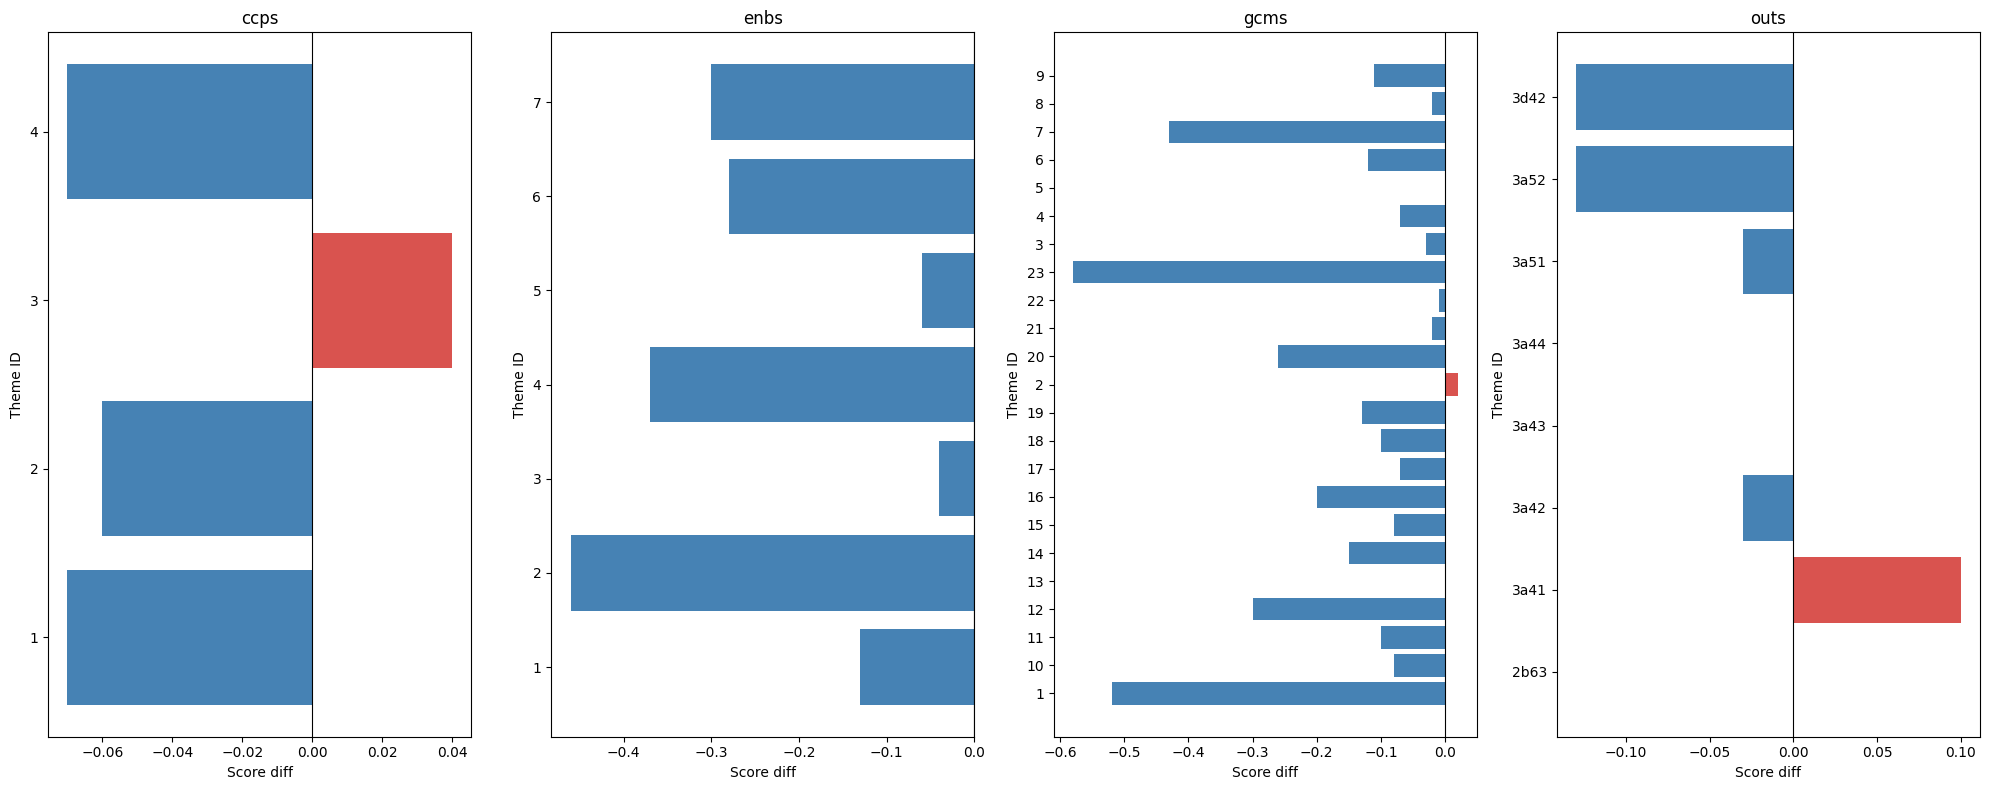

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
    colors = ['#d9534f' if x > 0 else 'steelblue' for x in grp.score_diff]
    ax.barh(grp.theme_id.astype(str), grp.score_diff, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(mt)
    ax.set_xlabel('Score diff')
    ax.set_ylabel('Theme ID')
plt.tight_layout()
plt.show()

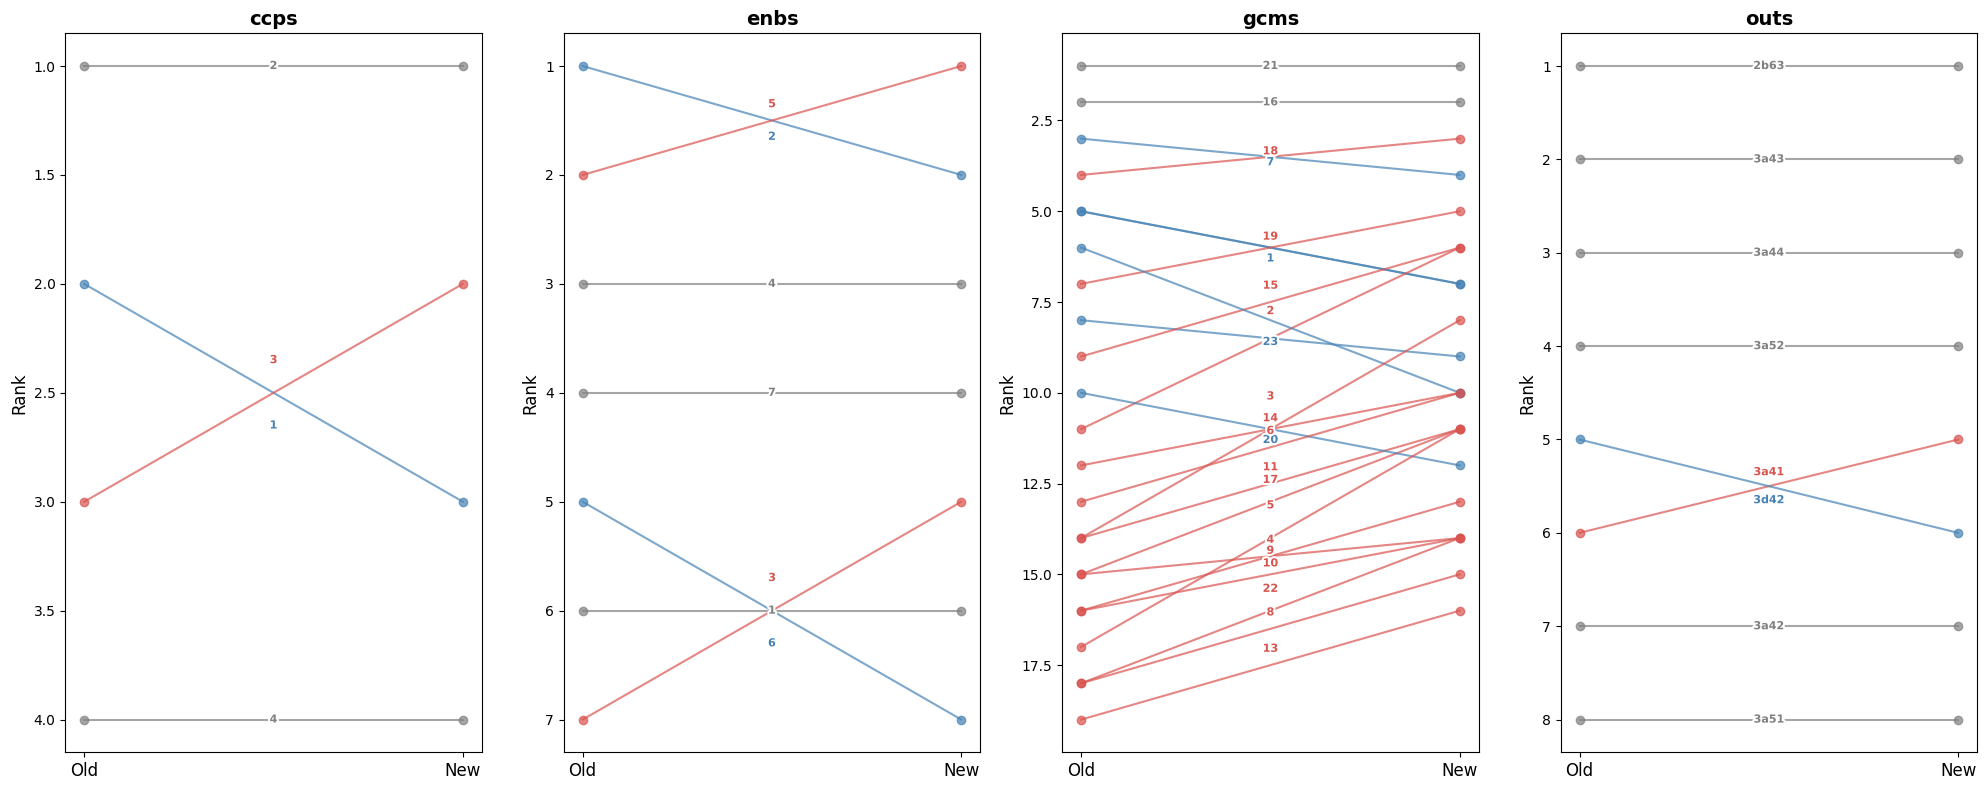

In [ ]:
from matplotlib.patheffects import withStroke

fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
    for _, row in grp.iterrows():
        color = 'steelblue' if row.rank_diff < 0 else '#d9534f' if row.rank_diff > 0 else 'grey'
        ax.plot([0, 1], [row.rank_old, row.rank_new], marker='o', color=color, alpha=0.7)
        mid_y = (row.rank_old + row.rank_new) / 2
        offset = -0.15 * row.rank_diff
        ax.text(0.5, mid_y + offset, row.theme_id, ha='center', va='center', fontsize=8, fontweight='bold',
                color=color, path_effects=[withStroke(linewidth=3, foreground='white')])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Old', 'New'], fontsize=12)
    ax.invert_yaxis()
    ax.set_title(mt, fontsize=14, fontweight='bold')
    ax.set_ylabel('Rank', fontsize=12)
plt.tight_layout()
plt.show()

I've remapped all $`current_res` reports, so I can compare mappings for all of them. What kind of questions could we ask?
- "does GCM 23 systematically get lower rank on average?"

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great starting point! Here are some useful directions:

**Systematic bias / directional shifts**
- Does a specific theme (e.g. GCM 23) consistently score lower / rank lower across reports?
- Which themes show the most consistent direction of change (always up or always down)?
- Are score drops concentrated in specific mapping types (e.g. `gcms` more affected than `ccps`)?

**Magnitude of change**
- Which themes have the largest average `|score_diff|` across reports?
- What's the distribution of `pct_change` — are most changes small noise or substantial?
- Are there outlier reports where changes are much larger than average?

**Rank stability**
- Which themes are most rank-stable (low variance in `rank_diff`) across reports?
- How often does the top-ranked theme change between old and new?

**Report-level**
- Which reports changed the most overall (e.g. mean `|score_diff|` per report)?
- Are there reports where the set of "high relevance" themes (e.g. score > 0.5) changed substantially?

**Cross-mapping consistency**
- Do reports that show a big drop in a GCM theme also show a drop in the related SRF output?

---

Your GCM 23 question is a good one to start with — it's essentially: *across all reports, what is the mean `rank_diff` for GCM 23?* Shall I write that up, along with a small summary table for all themes?

In [ ]:
df = compare_mappings(current_res[0], DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change)
df.head()

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
0,ccps,1,"Integrity, Transparency and Accountability",0.45,"Integrity, Transparency and Accountability",0.38,-0.07,False,False,2.0,3.0,-1.0,-15.555556
1,ccps,2,"Equality, Diversity & Inclusion",0.72,"Equality, Diversity & Inclusion",0.66,-0.06,False,False,1.0,1.0,0.0,-8.333333
2,ccps,3,Protection-centred,0.38,Protection-centred,0.42,0.04,False,False,3.0,2.0,1.0,10.526316
3,ccps,4,Environmental Sustainability,0.12,Environmental Sustainability,0.05,-0.07,False,False,4.0,4.0,0.0,-58.333333
4,enbs,1,Workforce,0.28,Workforce,0.15,-0.13,False,False,6.0,6.0,0.0,-46.428571


In [ ]:
dfs = pd.concat([
    compare_mappings(
        d, 
        DATA_PATH/'results', 
        LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change) 
    for d in current_res])

In [ ]:
dfs = pd.concat([
    compare_mappings(d, DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change)
    for d in current_res], ignore_index=True)

In [ ]:
dfs.head()

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
0,ccps,1,"Integrity, Transparency and Accountability",0.45,"Integrity, Transparency and Accountability",0.38,-0.07,False,False,2.0,3.0,-1.0,-15.555556
1,ccps,2,"Equality, Diversity & Inclusion",0.72,"Equality, Diversity & Inclusion",0.66,-0.06,False,False,1.0,1.0,0.0,-8.333333
2,ccps,3,Protection-centred,0.38,Protection-centred,0.42,0.04,False,False,3.0,2.0,1.0,10.526316
3,ccps,4,Environmental Sustainability,0.12,Environmental Sustainability,0.05,-0.07,False,False,4.0,4.0,0.0,-58.333333
4,enbs,1,Workforce,0.28,Workforce,0.15,-0.13,False,False,6.0,6.0,0.0,-46.428571


In [ ]:
dfs[(dfs.mapping_type=='gcms') & (dfs.theme_id=='23')]['pct_change'].describe()

count    20.000000
mean    -65.511802
std      23.376751
min     -86.956522
25%     -79.801829
50%     -74.264706
75%     -61.572967
max     -15.294118
Name: pct_change, dtype: float64

In [ ]:
dfs[(dfs.mapping_type=='gcms') & (dfs.theme_id=='23')].score_diff.describe()

count    20.000000
mean     -0.435000
std       0.188582
min      -0.800000
25%      -0.572500
50%      -0.440000
75%      -0.345000
max      -0.130000
Name: score_diff, dtype: float64

### Scores diff

<Axes: >

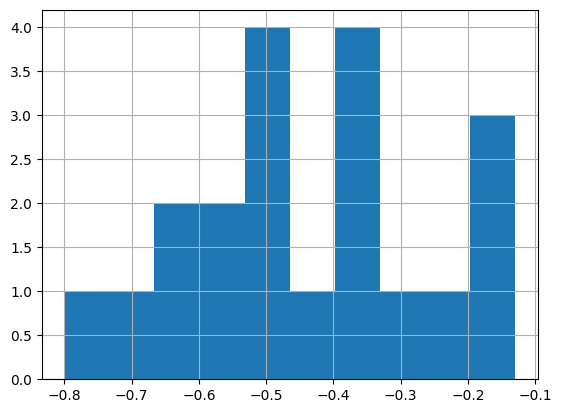

In [ ]:
dfs[(dfs.mapping_type=='gcms') & (dfs.theme_id=='23')].score_diff.hist()

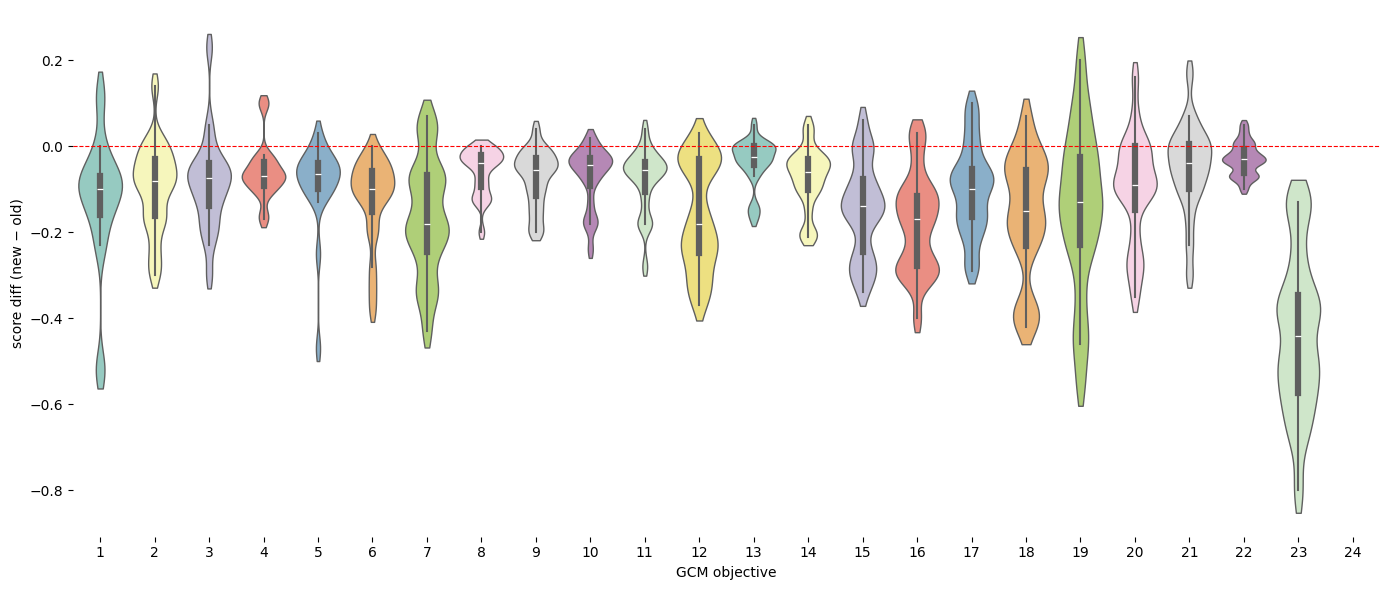

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

gcm_dfs = dfs[dfs.mapping_type=='gcms'].copy()
gcm_dfs['theme_id'] = gcm_dfs['theme_id'].astype(int)
gcm_dfs = gcm_dfs.sort_values('theme_id')

f, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=gcm_dfs, x='theme_id', y='score_diff', hue='theme_id', legend=False, bw_adjust=.5, cut=1, linewidth=1, palette="Set3")

ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.set(xlabel='GCM objective', ylabel='score diff (new − old)')
sns.despine(left=True, bottom=True)
plt.tight_layout()

In [ ]:
def plot_score_diffs(dfs, mapping_type, xlabel='Theme', col='score_diff'):
    "Violin plot of score diffs (new − old) per theme for a given mapping type"
    d = dfs[dfs.mapping_type==mapping_type].copy()
    d['theme_id'] = d['theme_id'].astype(int)
    d = d.sort_values('theme_id')
    f, ax = plt.subplots(figsize=(14, 6))
    sns.violinplot(data=d, x='theme_id', y=col, hue='theme_id', legend=False, bw_adjust=.5, cut=1, linewidth=1, palette="Set3")
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set(xlabel=xlabel, ylabel=f'{col} (new − old)', title=mapping_type)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

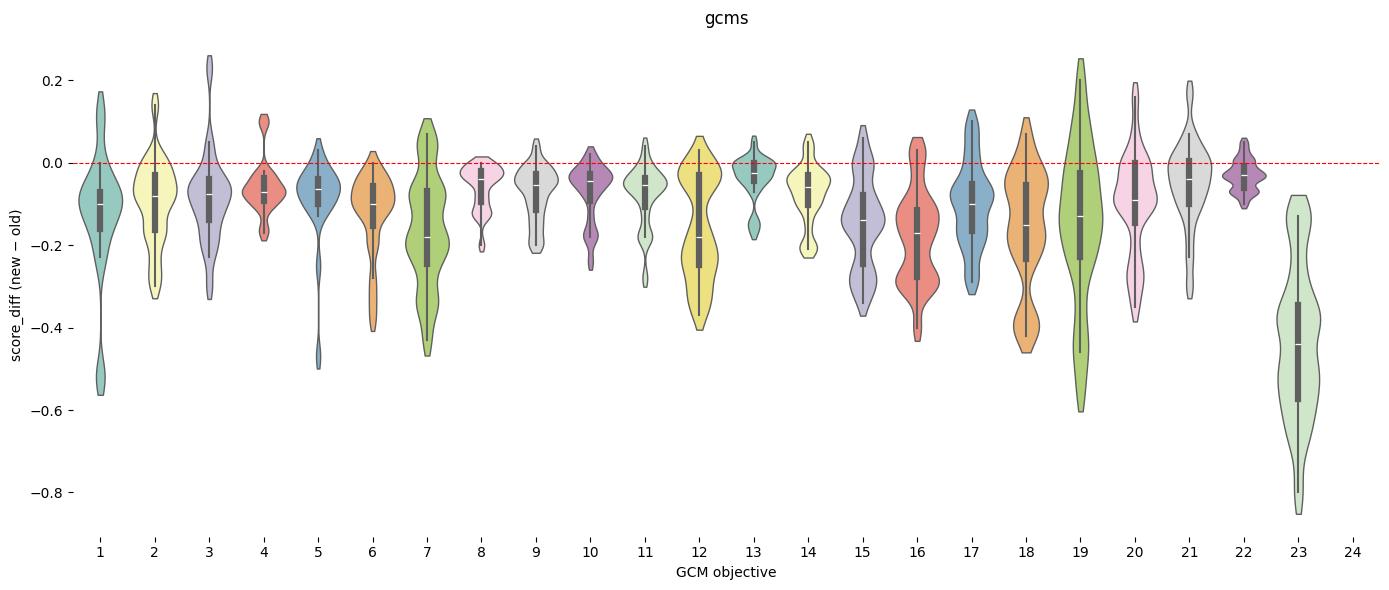

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective')

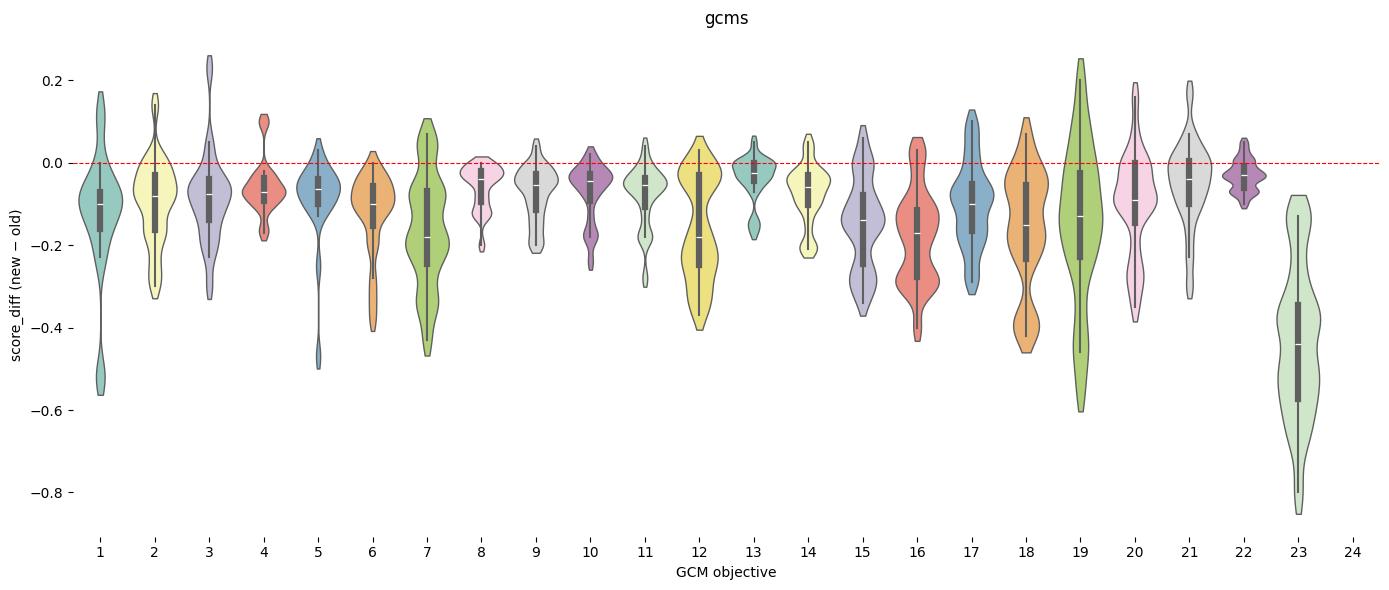

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective')

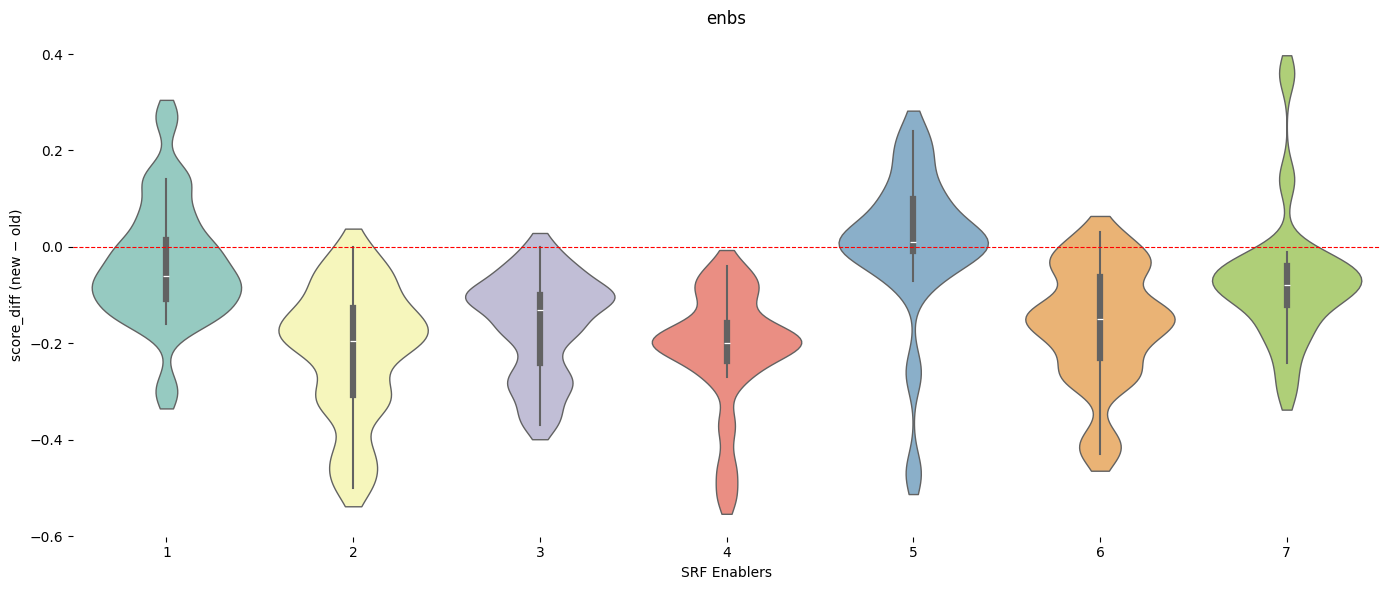

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers')

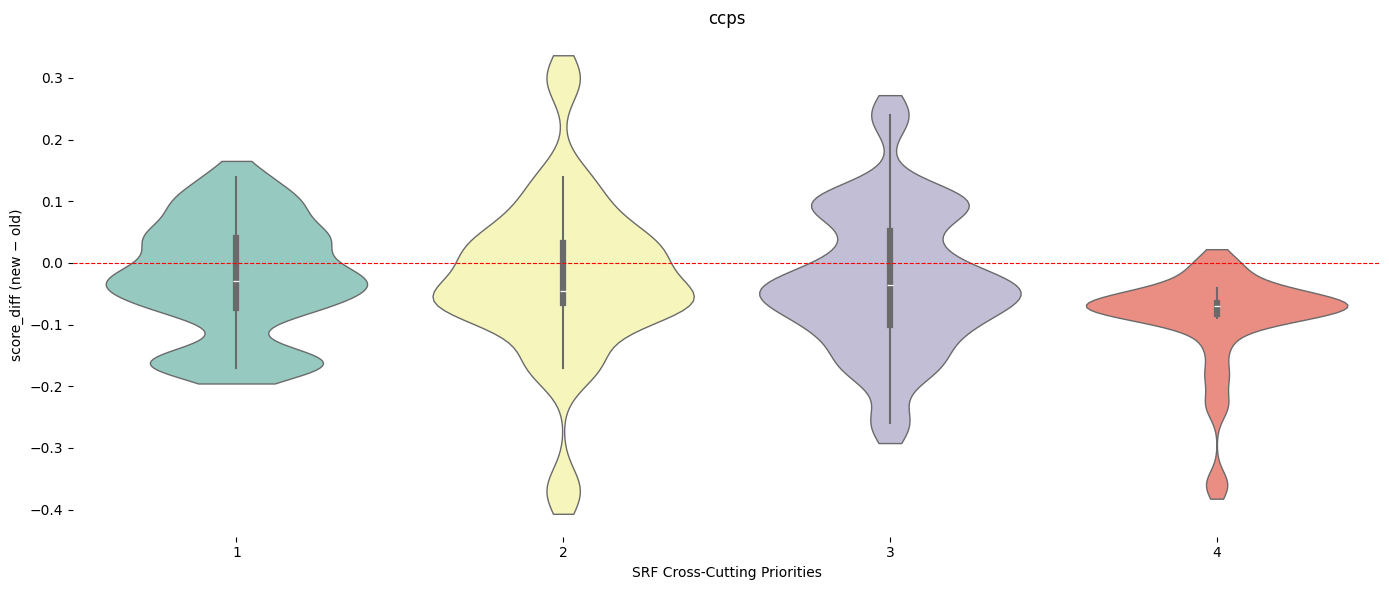

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities')

In [ ]:
dfs.columns

Index(['mapping_type', 'theme_id', 'theme_title_x', 'score_old',
       'theme_title_y', 'score_new', 'score_diff', 'is_new', 'is_dropped',
       'rank_old', 'rank_new', 'rank_diff', 'pct_change'],
      dtype='str')

### Ranks diff

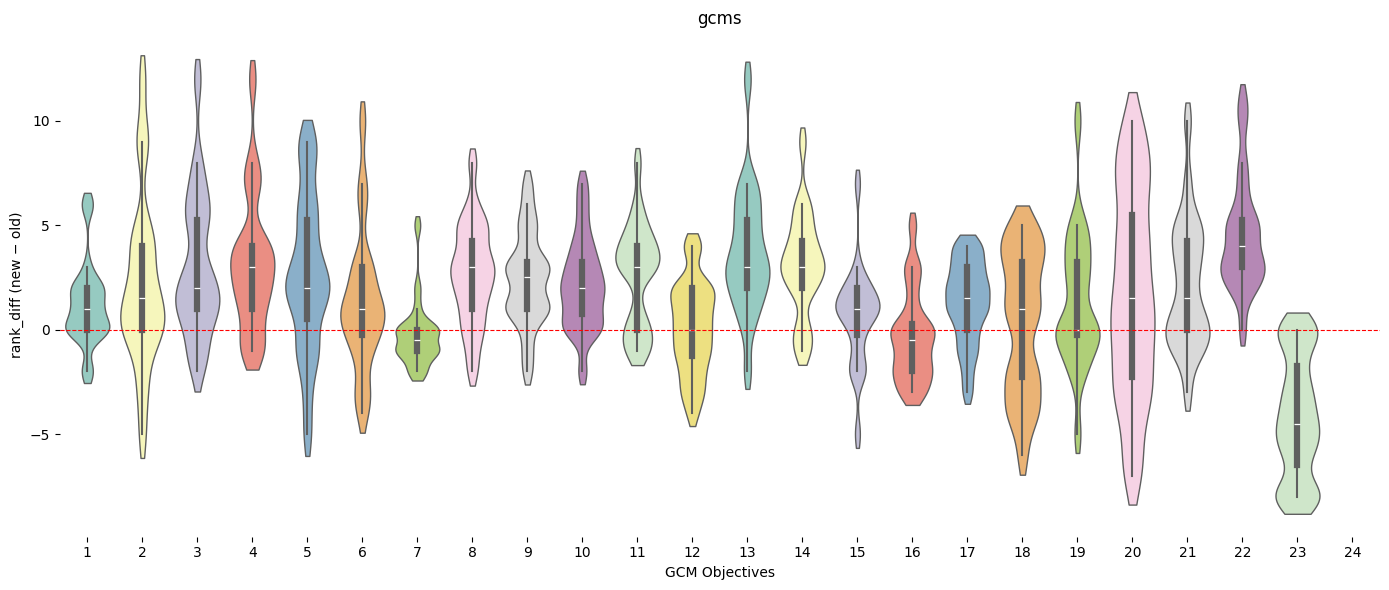

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM Objectives', col='rank_diff')

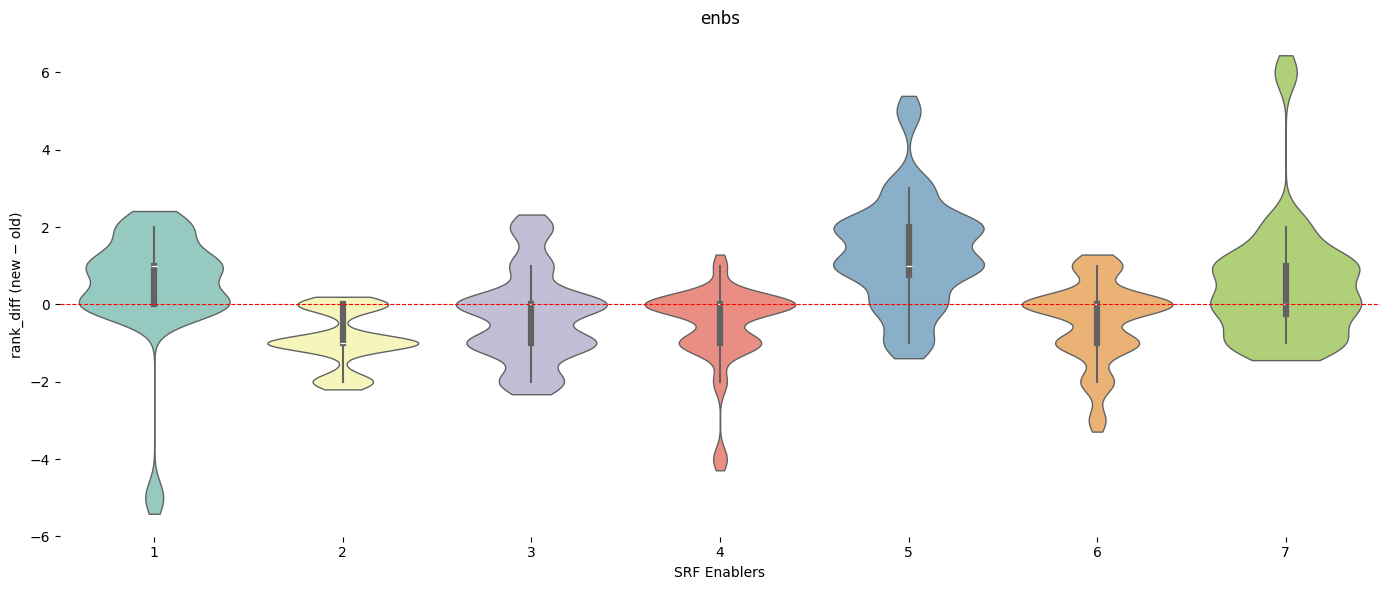

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers', col='rank_diff')

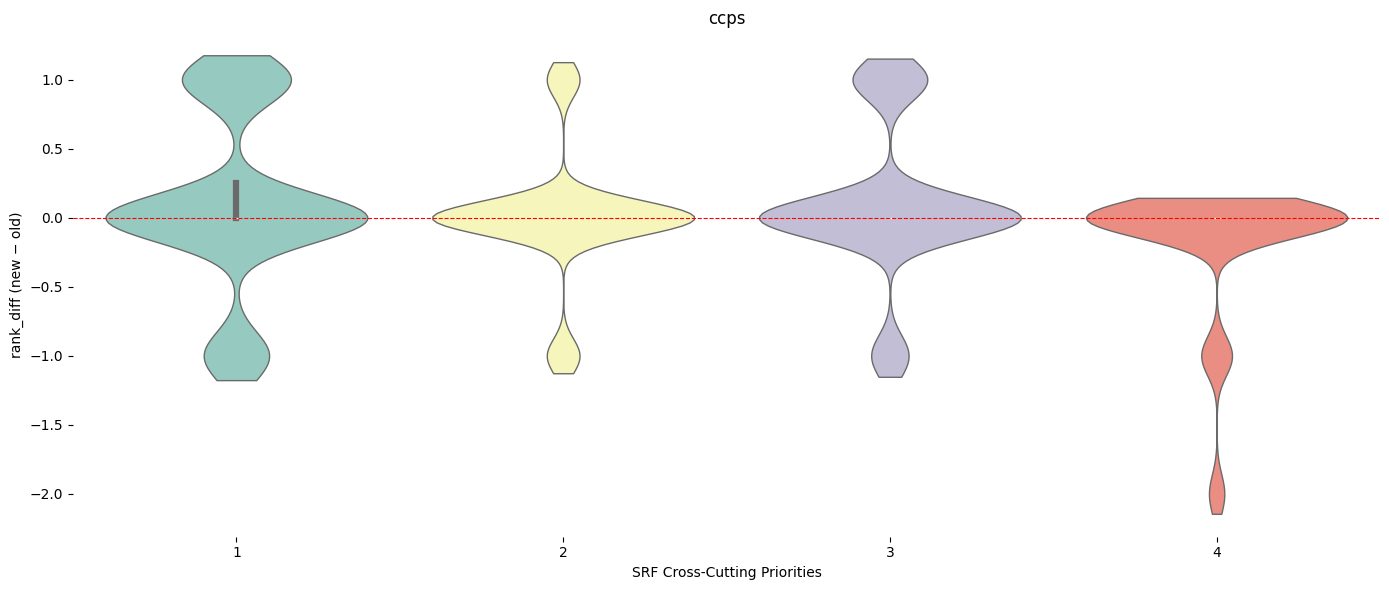

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities', col='rank_diff')

In [ ]:
plot_score_diffs(dfs[dfs.rank_old <= 3], 'gcms', 'GCM Objectives', col='rank_diff')

Let's try to answer this question: How often does the top-ranked theme change between old and new?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

We need to track, per report and mapping type, whether the top-ranked theme changed. We'll need an `eval_id` column first — let me rebuild `dfs` with that, then answer the question.

```python
dfs = pd.concat([
    compare_mappings(d, DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change).assign(eval_id=d)
    for d in current_res], ignore_index=True)
```

Then:

```python
def top_theme(df, rank_col): return df[df[rank_col]==1].set_index(['eval_id','mapping_type'])['theme_id']

top_old = top_theme(dfs, 'rank_old')
top_new = top_theme(dfs, 'rank_new')
top_changed = (top_old != top_new).rename('changed')
top_changed.groupby('mapping_type').mean().mul(100).round(1).rename('% reports where top theme changed')
```

In [ ]:
dfs = pd.concat([
    compare_mappings(d, DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change).assign(eval_id=d)
    for d in current_res], ignore_index=True)

In [ ]:
def top_theme(df, rank_col): return df[df[rank_col]==1].set_index(['eval_id','mapping_type'])['theme_id']

top_old = top_theme(dfs, 'rank_old')
top_new = top_theme(dfs, 'rank_new')
top_changed = (top_old != top_new).rename('changed')
top_changed.groupby('mapping_type').mean().mul(100).round(1).rename('% reports where top theme changed')

mapping_type
ccps    20.0
enbs    55.0
gcms    25.0
outs    20.0
Name: % reports where top theme changed, dtype: float64

### Reports and mapping type where top ranked theme changed

In [ ]:
print(top_changed[top_changed].reset_index()[['eval_id','mapping_type']].sort_values('mapping_type'))

                             eval_id mapping_type
20  4c04ec0d3e651f7616190c6fc2dcfc18         ccps
5   22cac1c000836253adc445993e101560         ccps
18  891448b7a4bf12763ea0579dd67e289d         ccps
15  dba9eb1220368d28682d8531108e767d         ccps
0   8dd2261100ff5d714e73b411eed043d5         enbs
1   1d7e6d2d445145d1d350b48b72b36681         enbs
2   760568a15e144bcfb88dbbd50247dc51         enbs
21  e21305a89aeb76fafa8f4270392d463a         enbs
17  06fd0949dc874f388686461c19d2669c         enbs
8   316c47c9dc19c820f3217434d4b93b28         enbs
16  a493c447cff3e03ca94024335d5c5c7a         enbs
10  0d4309b702e00faac631be8d609934ce         enbs
12  e8d9427f4a9094f68e17307faa567d8b         enbs
13  75bad4665ed458cce78740e3d86f72d0         enbs
14  f409b3f9a0671ec69a8591c425a45c1d         enbs
11  0d4309b702e00faac631be8d609934ce         gcms
9   316c47c9dc19c820f3217434d4b93b28         gcms
6   22cac1c000836253adc445993e101560         gcms
3   760568a15e144bcfb88dbbd50247dc51         gcms


In [ ]:
def plot_rank_changes(df):
    "Slope chart of rank changes (old → new) per mapping type, coloured by direction"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        for _, row in grp.iterrows():
            color = 'steelblue' if row.rank_diff < 0 else '#d9534f' if row.rank_diff > 0 else 'grey'
            ax.plot([0, 1], [row.rank_old, row.rank_new], marker='o', color=color, alpha=0.7)
            ax.text(0.5, (row.rank_old + row.rank_new) / 2 + (-0.15 * row.rank_diff), row.theme_id,
                    ha='center', va='center', fontsize=8, fontweight='bold', color=color,
                    path_effects=[withStroke(linewidth=3, foreground='white')])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Old', 'New'], fontsize=12)
        ax.invert_yaxis()
        ax.set_title(mt, fontsize=14, fontweight='bold')
        ax.set_ylabel('Rank', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
#dfs[dfs.eval_id == '0d4309b702e00faac631be8d609934ce']

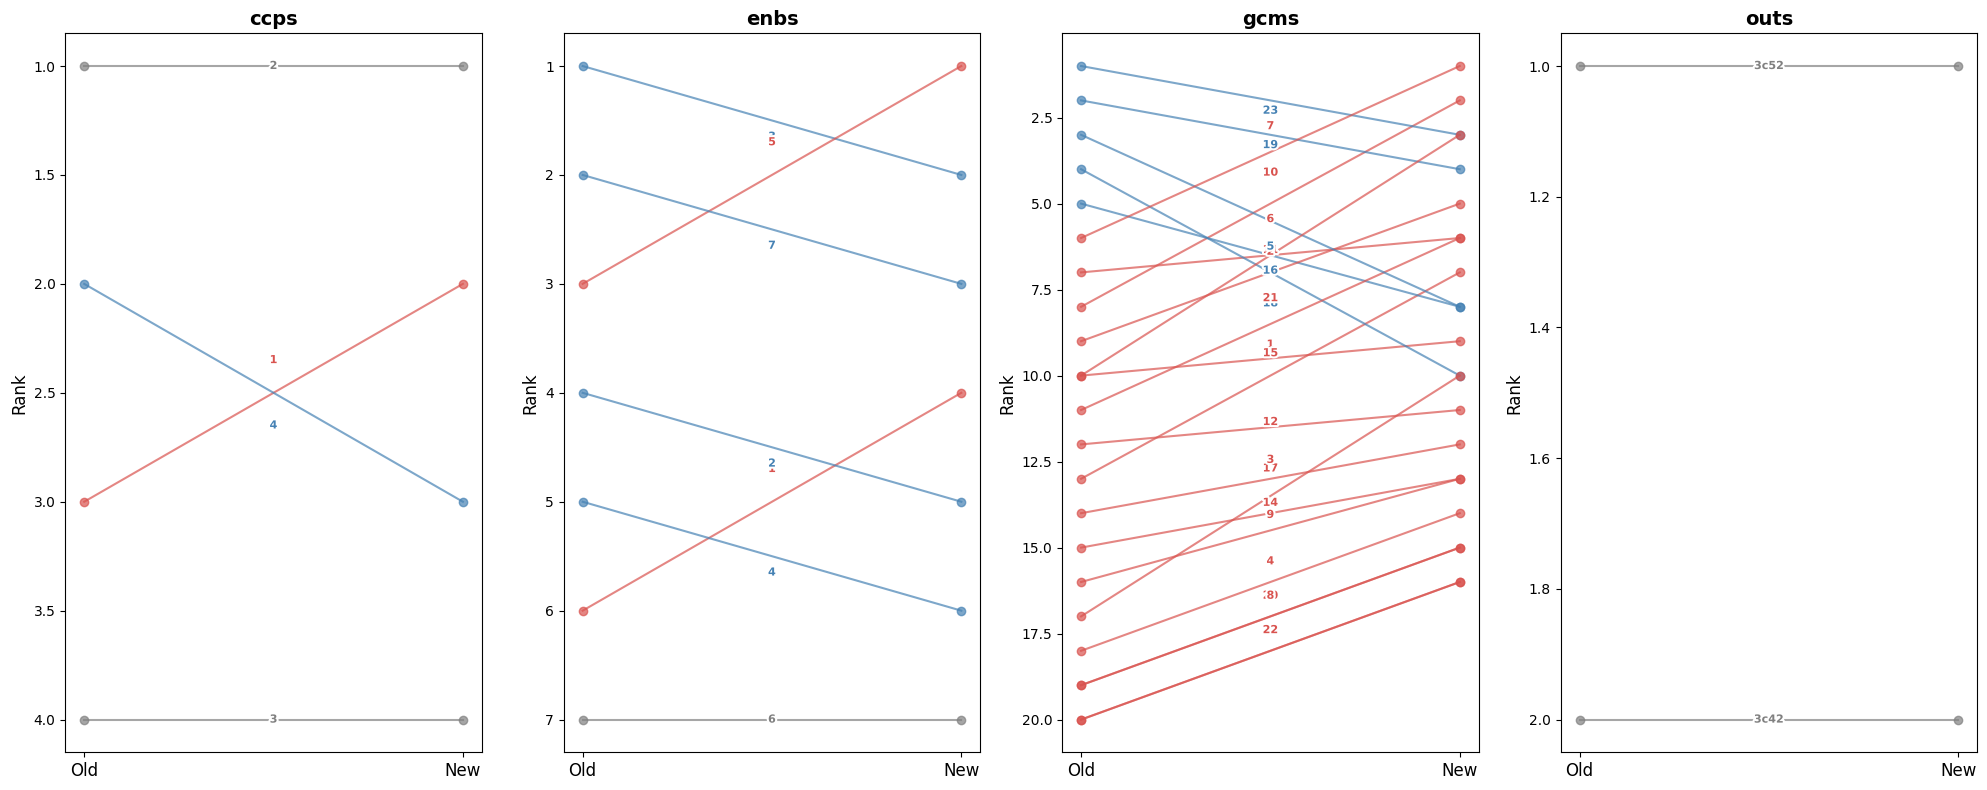

In [ ]:
plot_rank_changes(dfs[dfs.eval_id == '0d4309b702e00faac631be8d609934ce'])

In [ ]:
def info_eval(evl_id):
    return first([o for o in evals if o.id == evl_id])

In [ ]:
info_eval('0d4309b702e00faac631be8d609934ce')


### Fifth Evaluation of the IOM Development Fund
**Year:** 2025 | **Organization:** IOM | **Countries:** Worldwide

**Documents:** 5 available  
**ID:** `0d4309b702e00faac631be8d609934ce`


In [ ]:
def plot_score_diffs_bar(df):
    "Bar chart of score diffs (new − old) per theme, coloured by direction, faceted by mapping type"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        ax.barh(grp.theme_id.astype(str), grp.score_diff, color=['#d9534f' if x > 0 else 'steelblue' for x in grp.score_diff])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set(title=mt, xlabel='Score diff', ylabel='Theme ID')
    plt.tight_layout()
    plt.show()

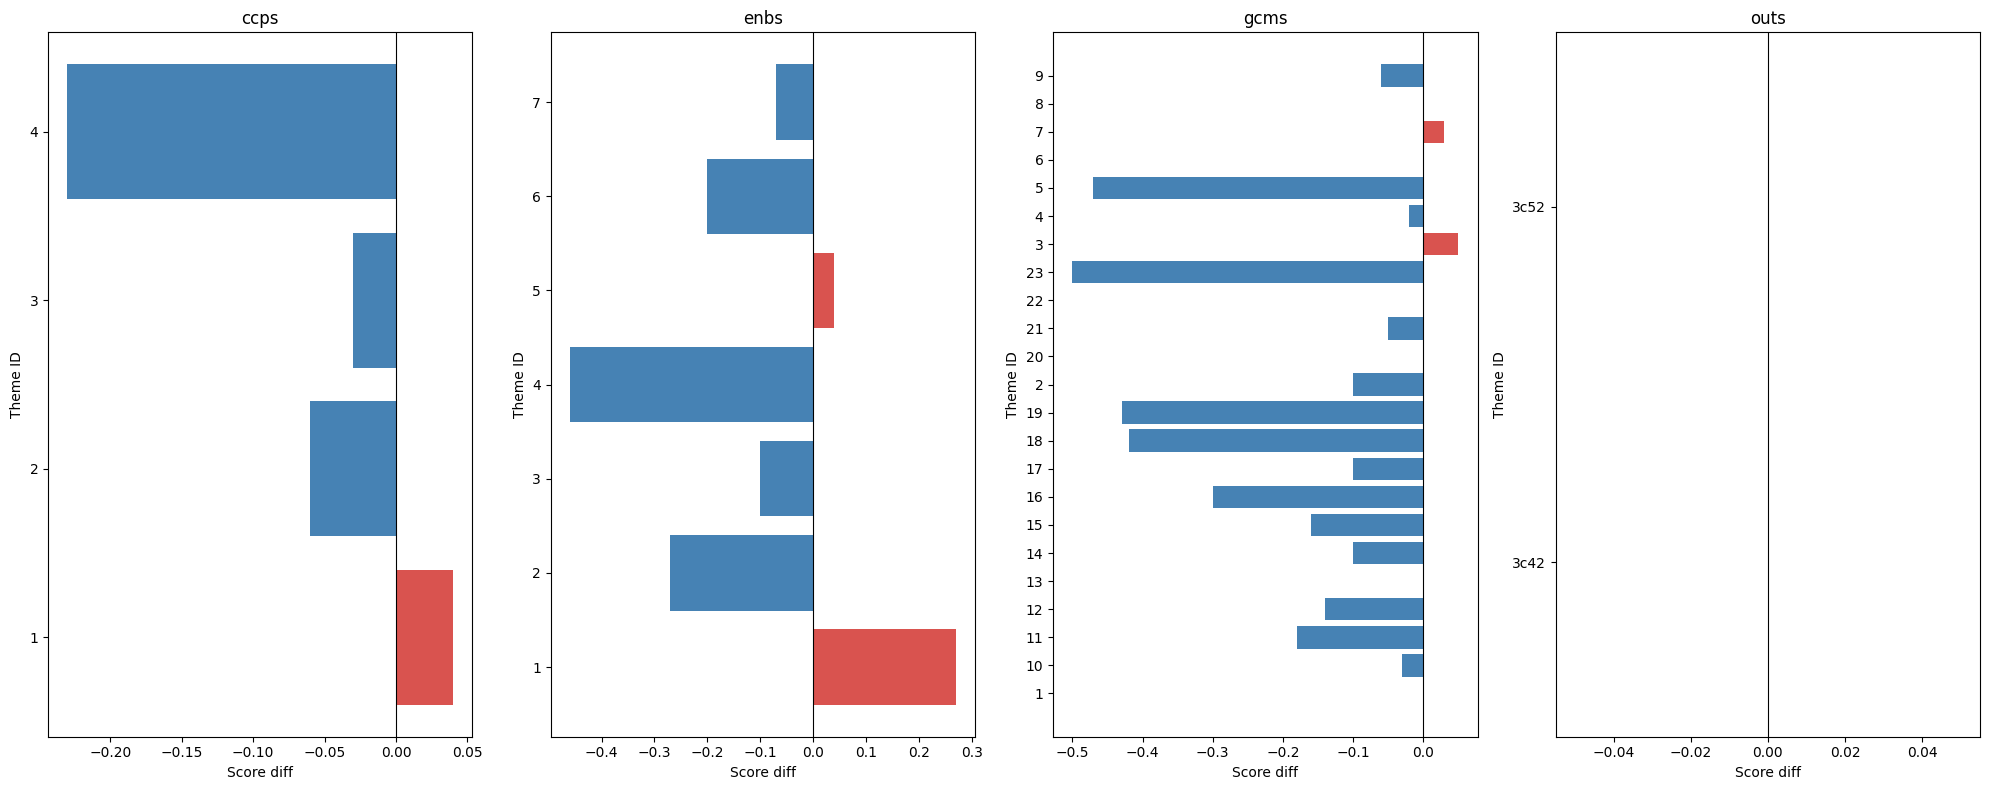

In [ ]:
plot_score_diffs_bar(dfs[dfs.eval_id == '0d4309b702e00faac631be8d609934ce'])

In [ ]:
def plot_scores_comparison(df, eval_id, mapping_type):
    "Grouped bar chart of old vs new scores per theme for a given report and mapping type"
    title = info_eval(eval_id).meta['Title']
    title_pretty = title if len(title) < 80 else title[:80] + '...'
    d = df[(df.eval_id==eval_id) & (df.mapping_type==mapping_type)].copy()
    d['theme_id'] = d['theme_id'].astype(int)
    d = d.sort_values('theme_id')
    x = range(len(d))
    f, ax = plt.subplots(figsize=(14, 5))
    ax.bar([i-0.2 for i in x], d.score_old, width=0.4, label='old', color='steelblue', alpha=0.8)
    ax.bar([i+0.2 for i in x], d.score_new, width=0.4, label='new', color='#d9534f', alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(d.theme_id)
    ax.set(xlabel='Theme ID', ylabel='Score', title=f'{mapping_type} — {title_pretty}')
    ax.legend()
    plt.tight_layout()

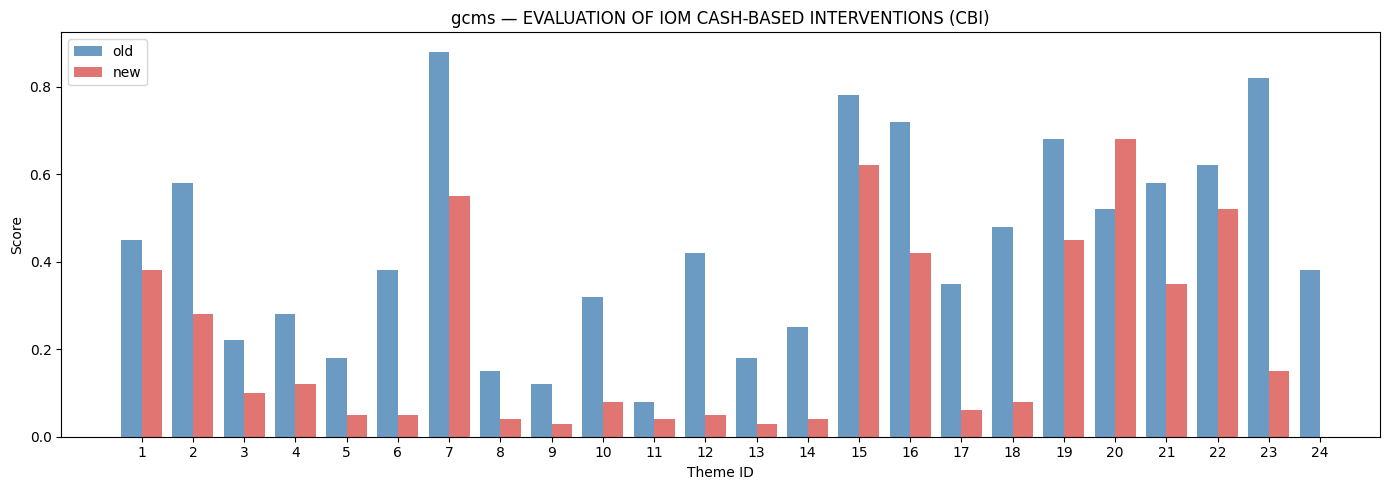

In [ ]:
plot_scores_comparison(dfs, '316c47c9dc19c820f3217434d4b93b28', 'gcms')

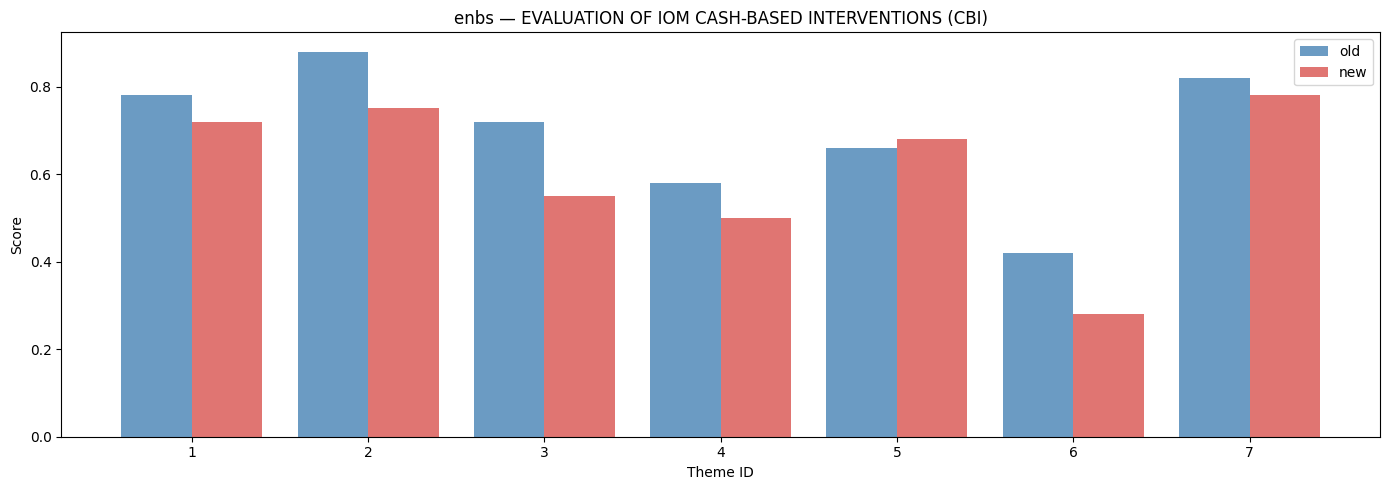

In [ ]:
plot_scores_comparison(dfs, '316c47c9dc19c820f3217434d4b93b28', 'enbs')

In [ ]:
df_top_changed = top_changed[top_changed].reset_index()[['eval_id','mapping_type']]

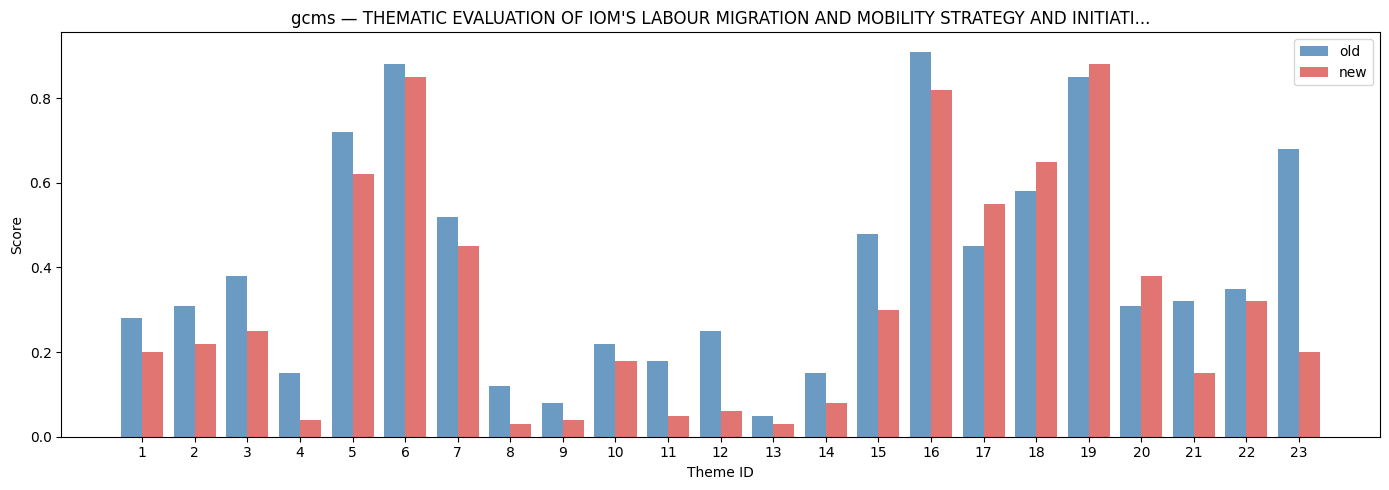

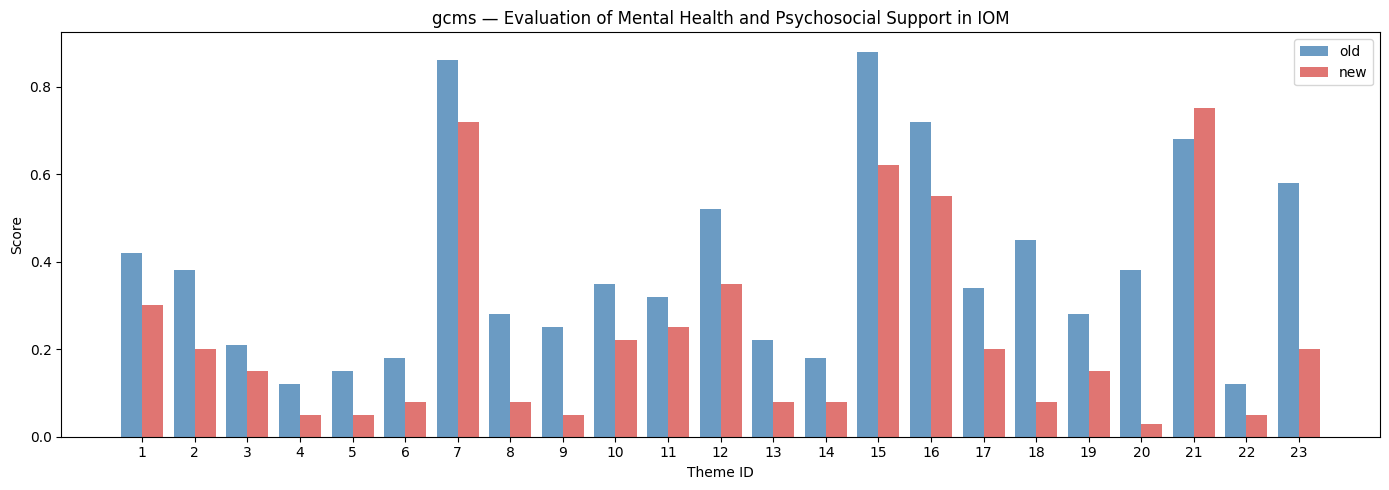

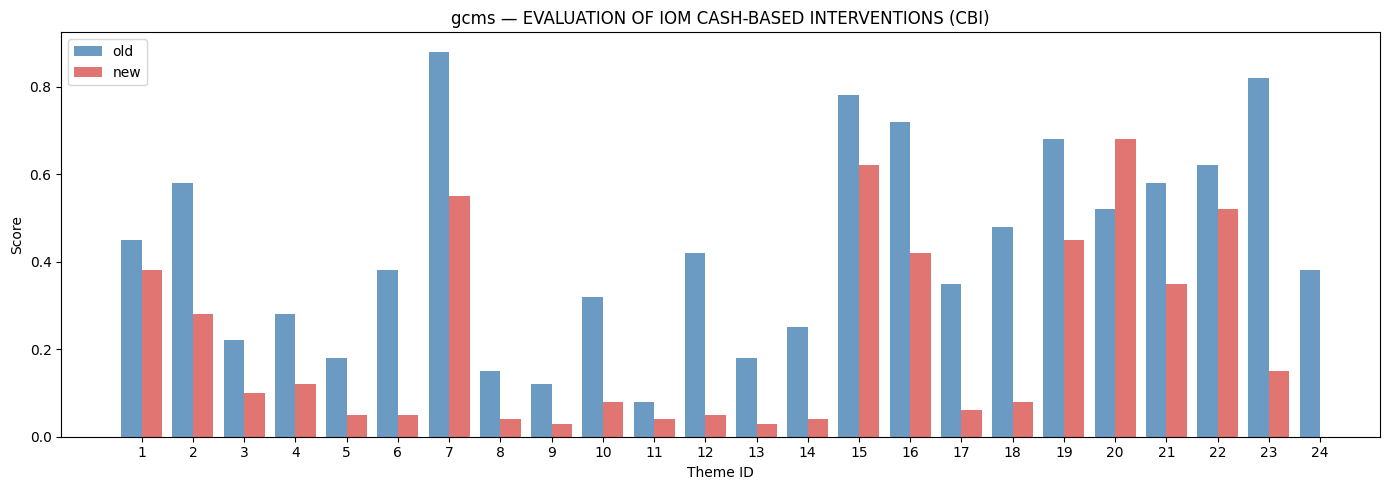

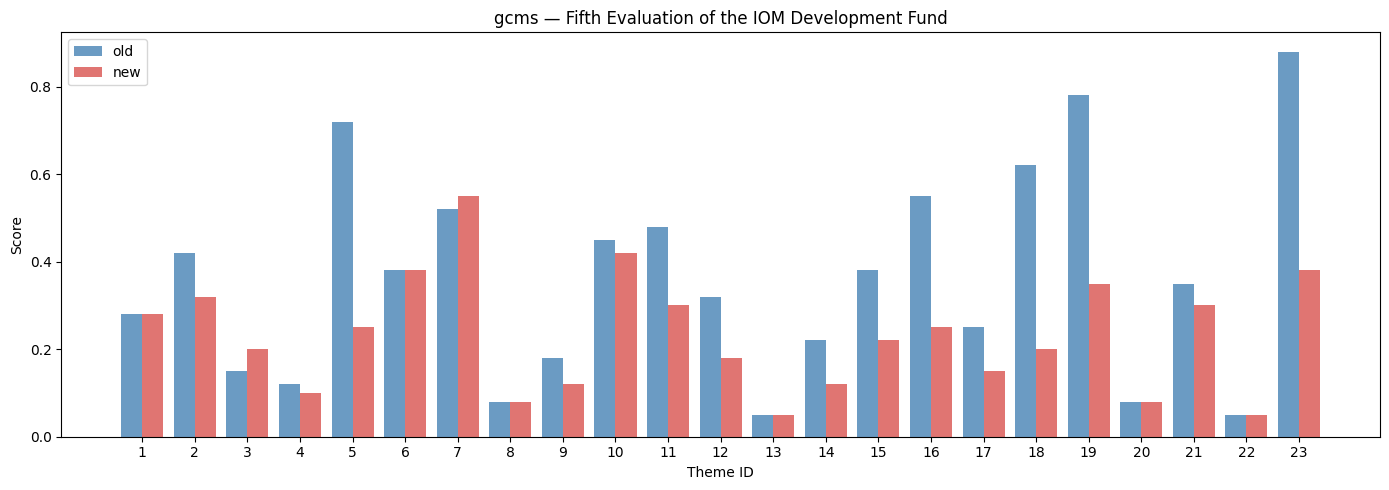

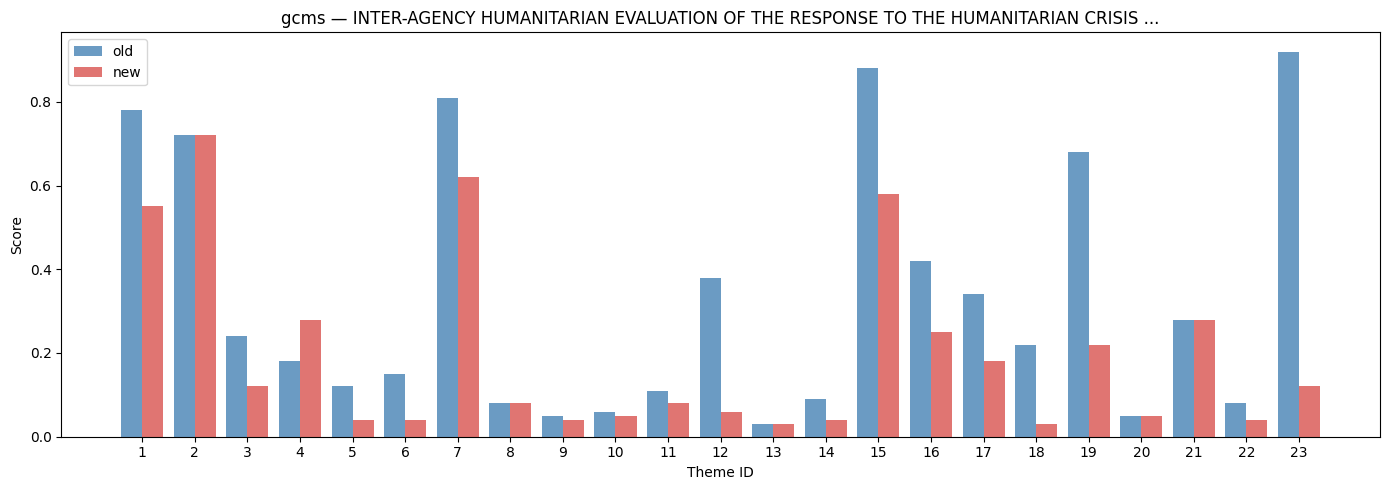

In [ ]:
for id_ in df_top_changed[df_top_changed.mapping_type == 'gcms'].eval_id:
    plot_scores_comparison(dfs, id_, 'gcms')

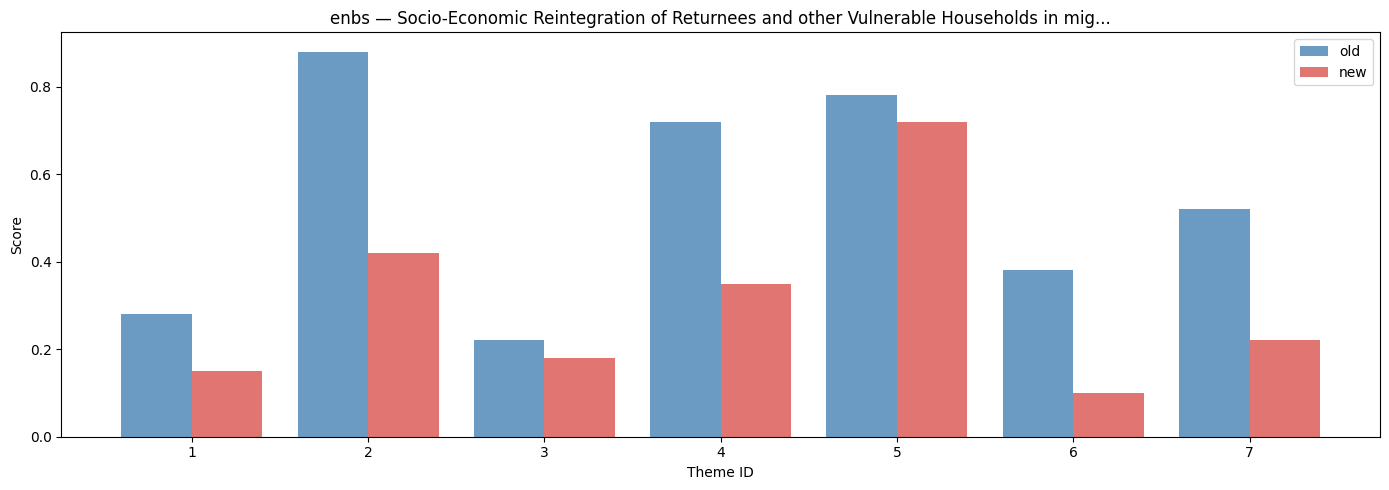

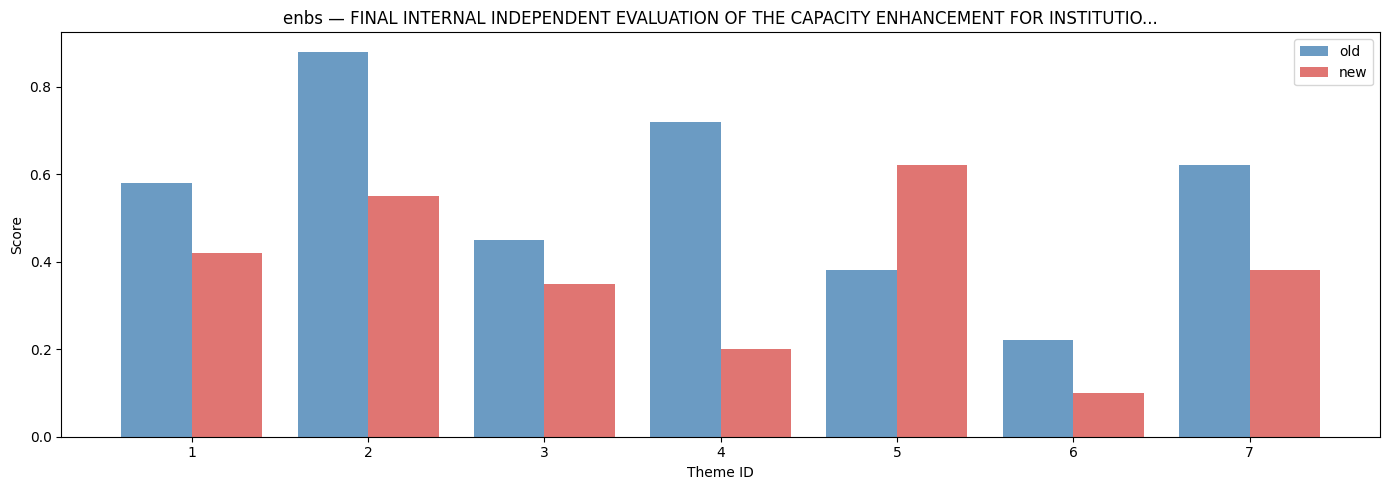

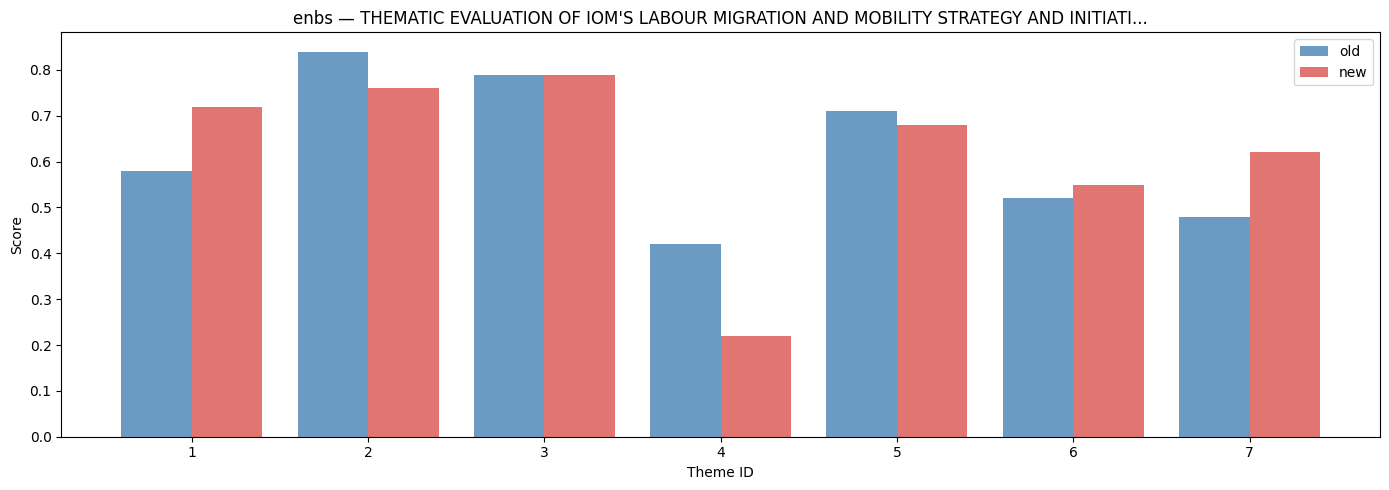

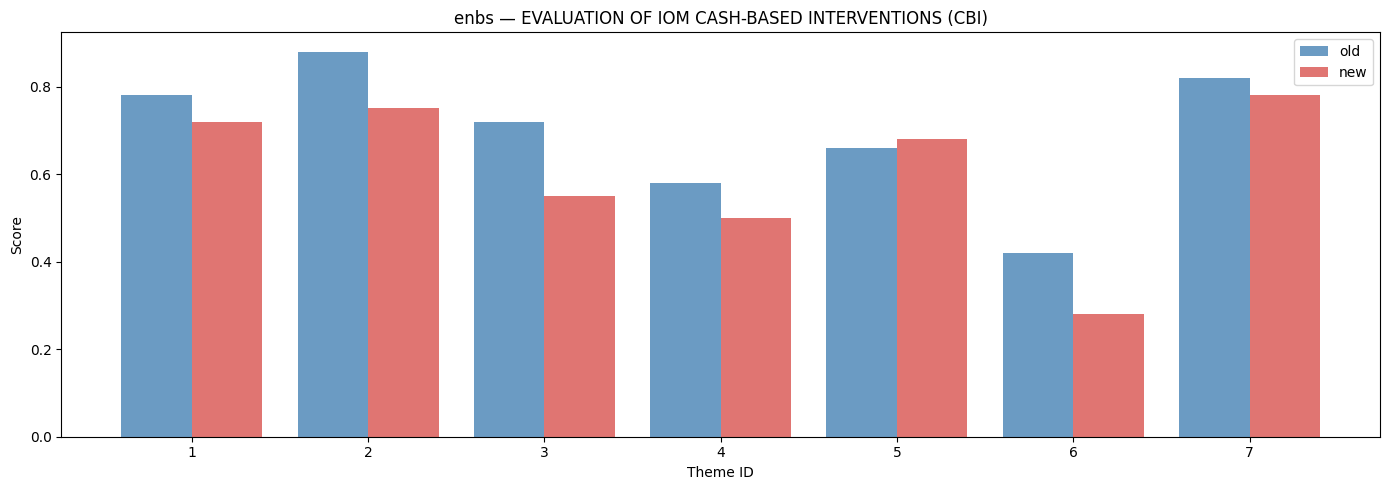

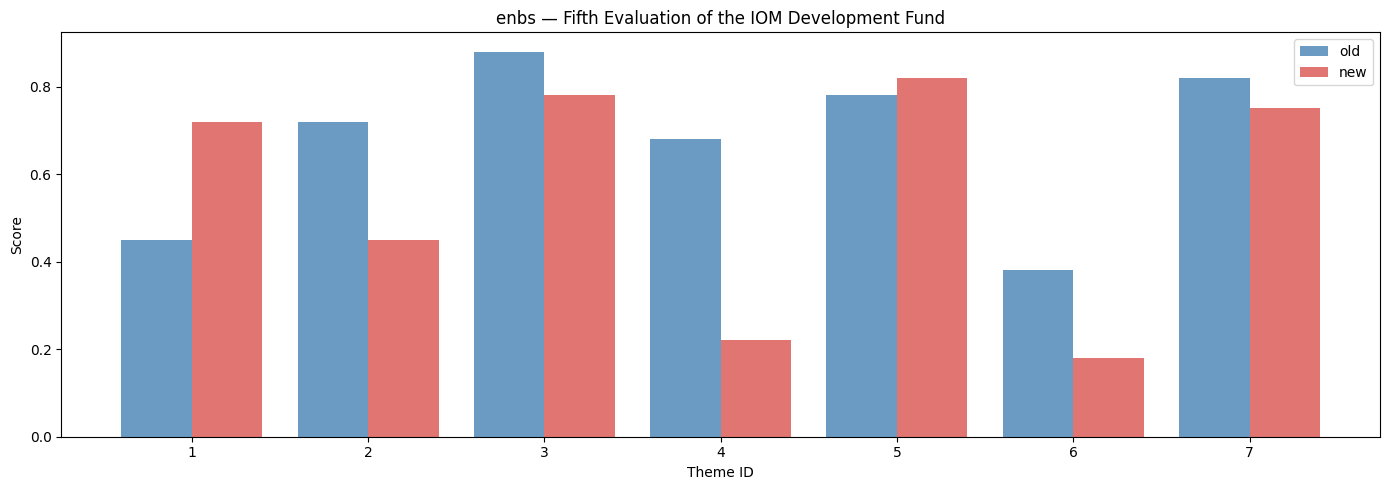

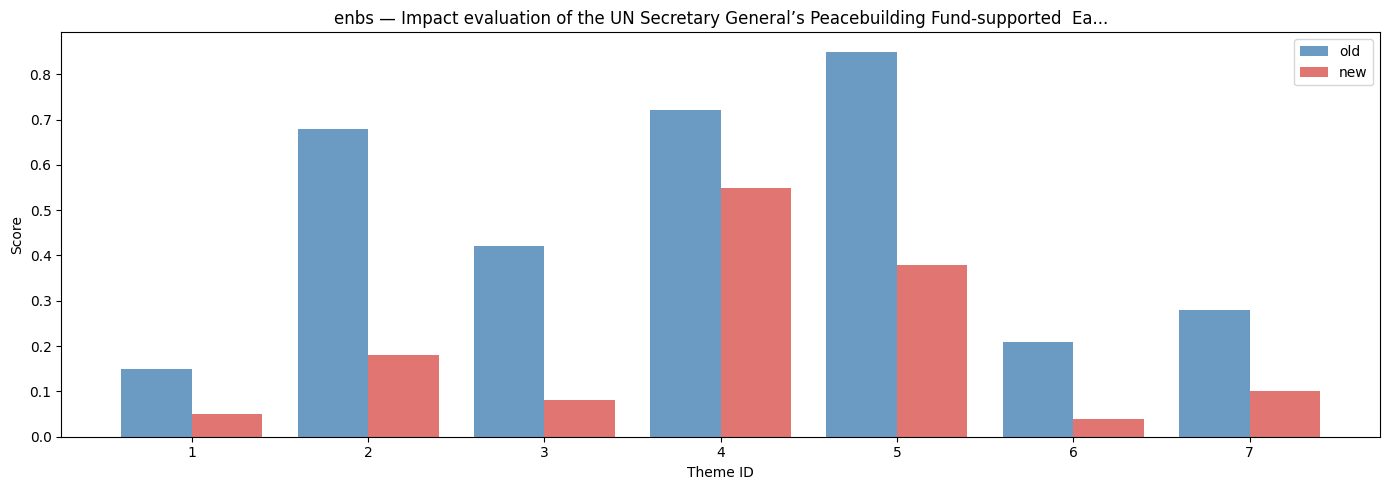

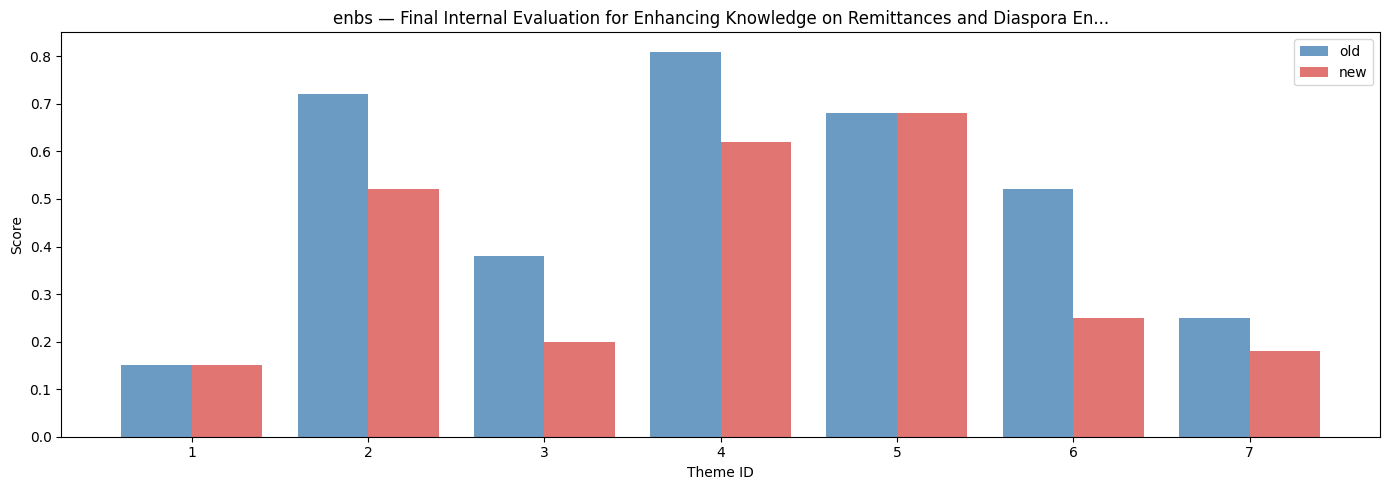

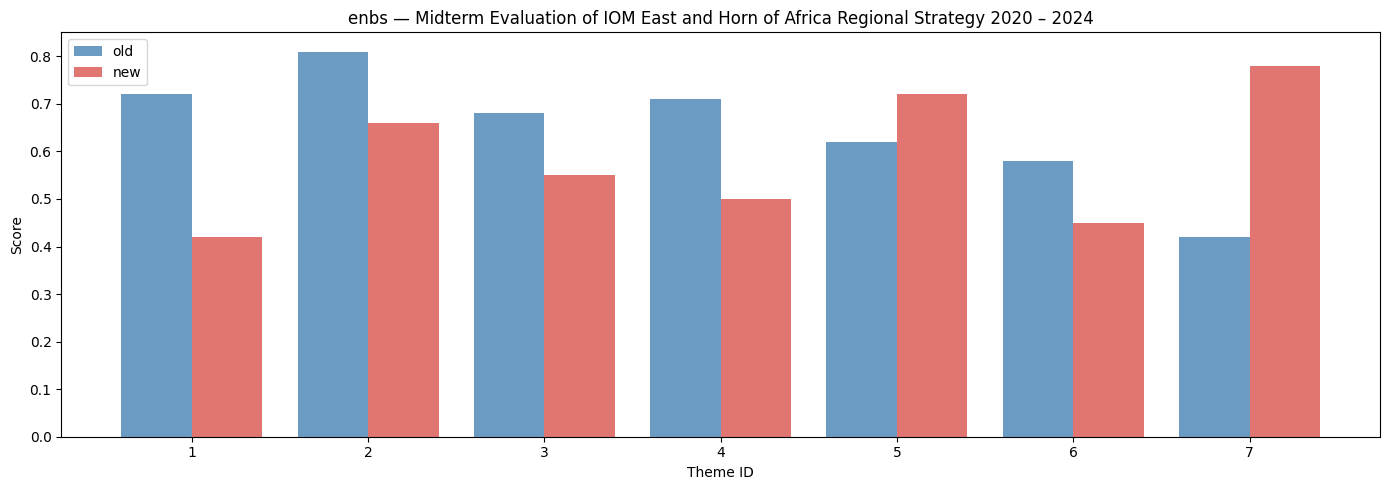

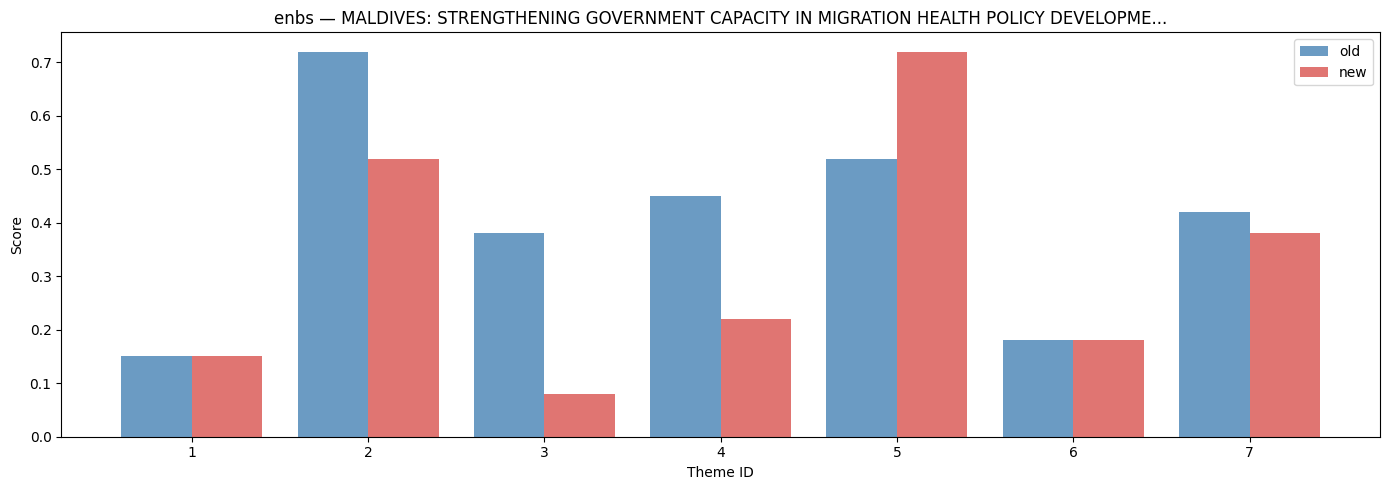

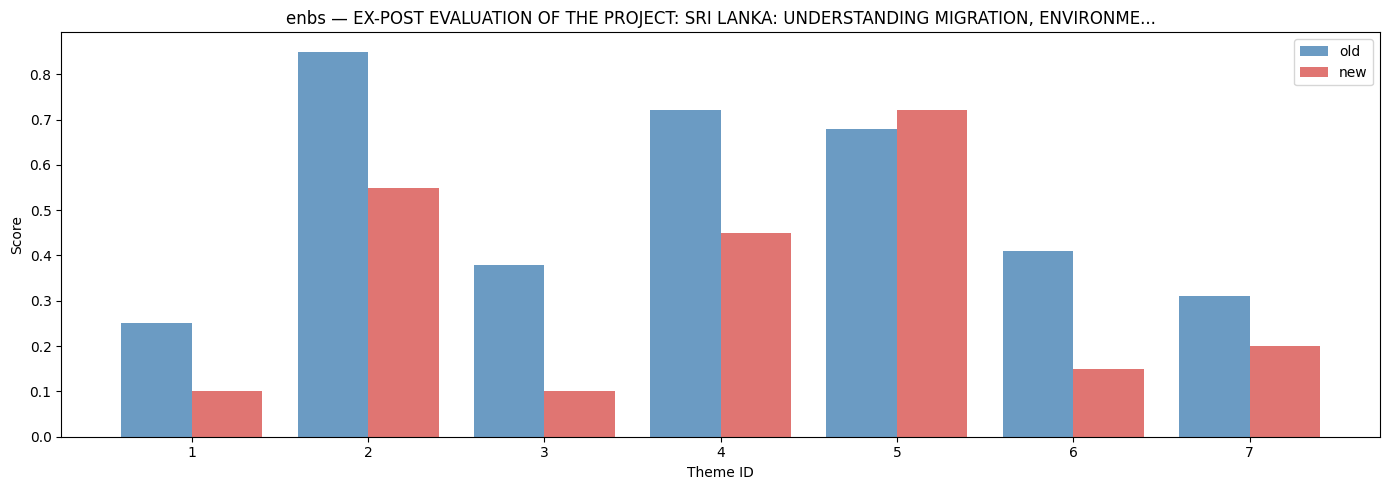

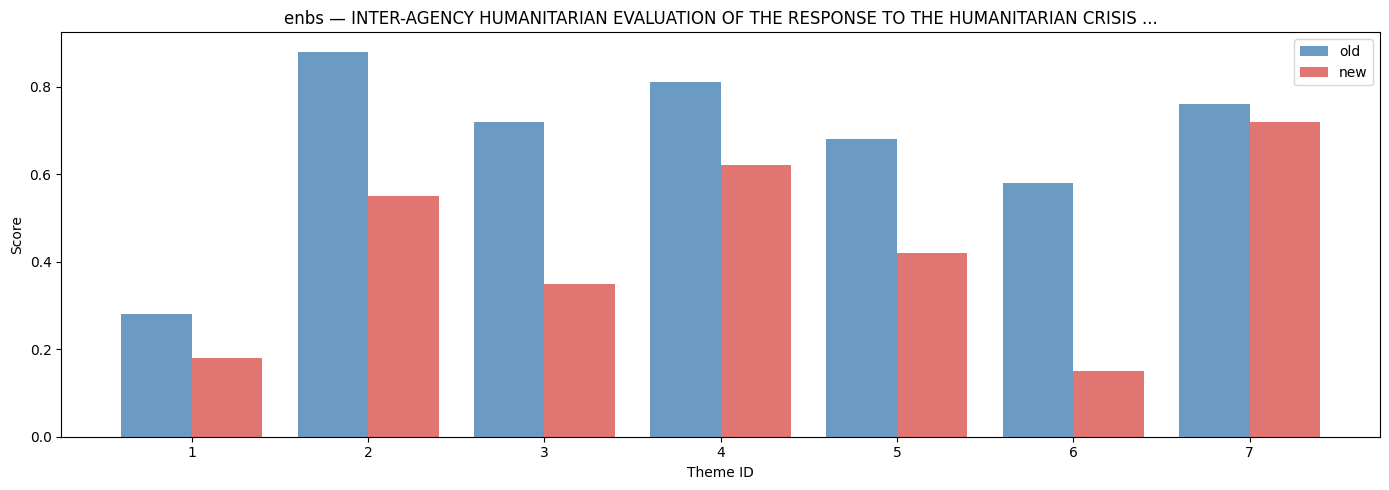

In [ ]:
for id_ in df_top_changed[df_top_changed.mapping_type == 'enbs'].eval_id:
    plot_scores_comparison(dfs, id_, 'enbs')



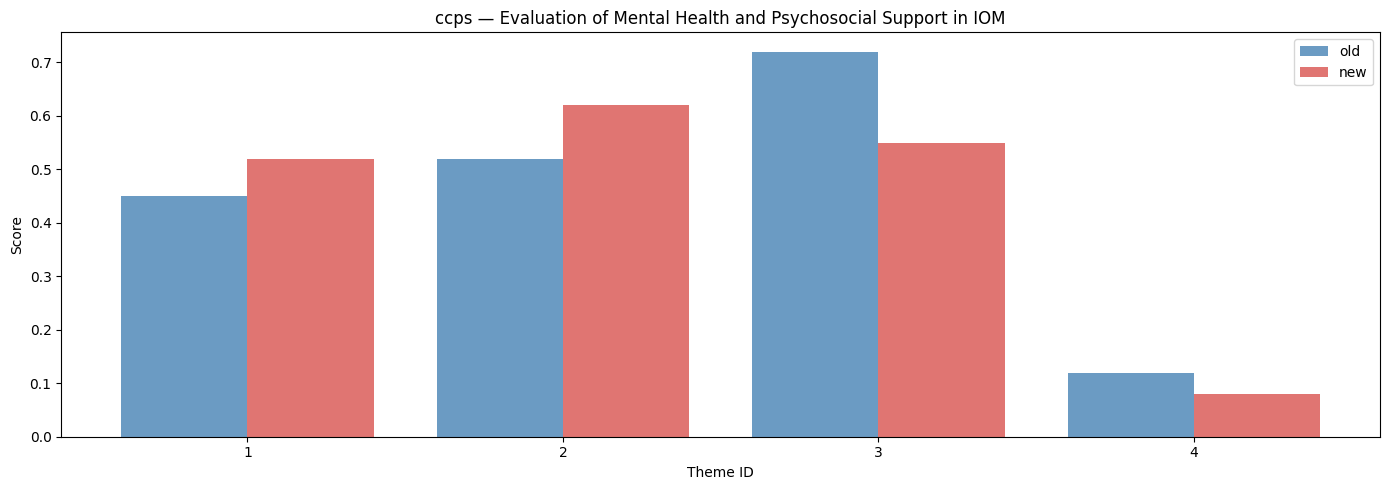

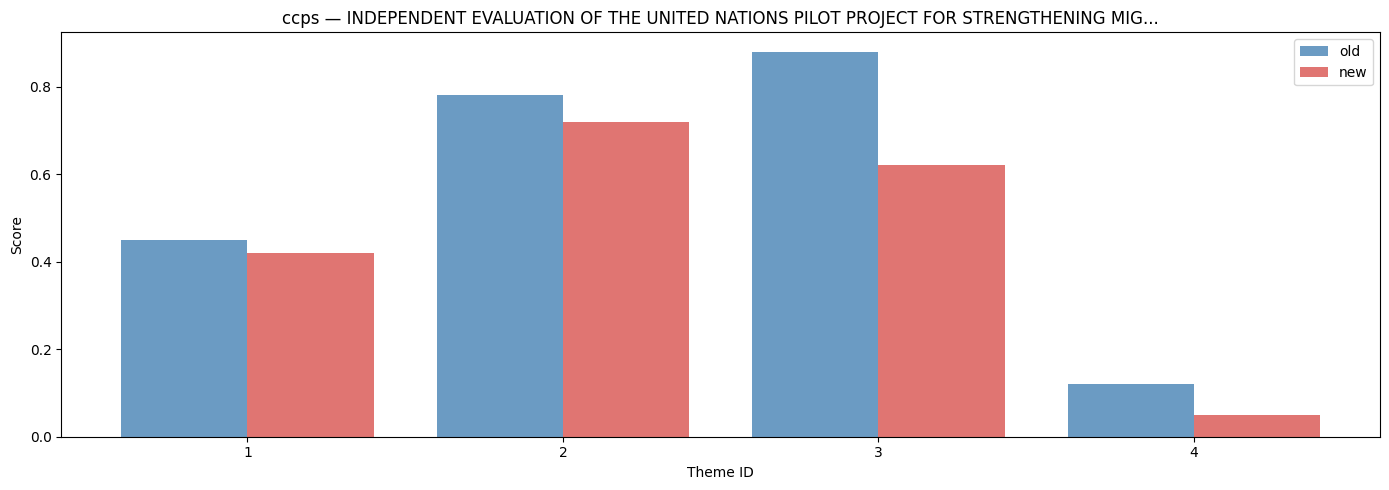

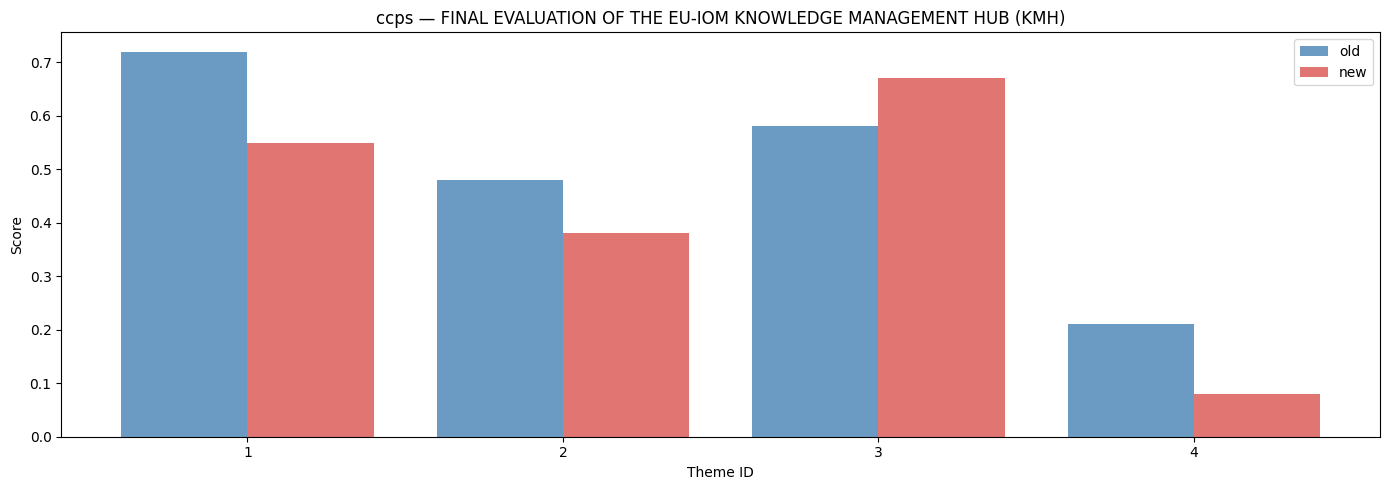

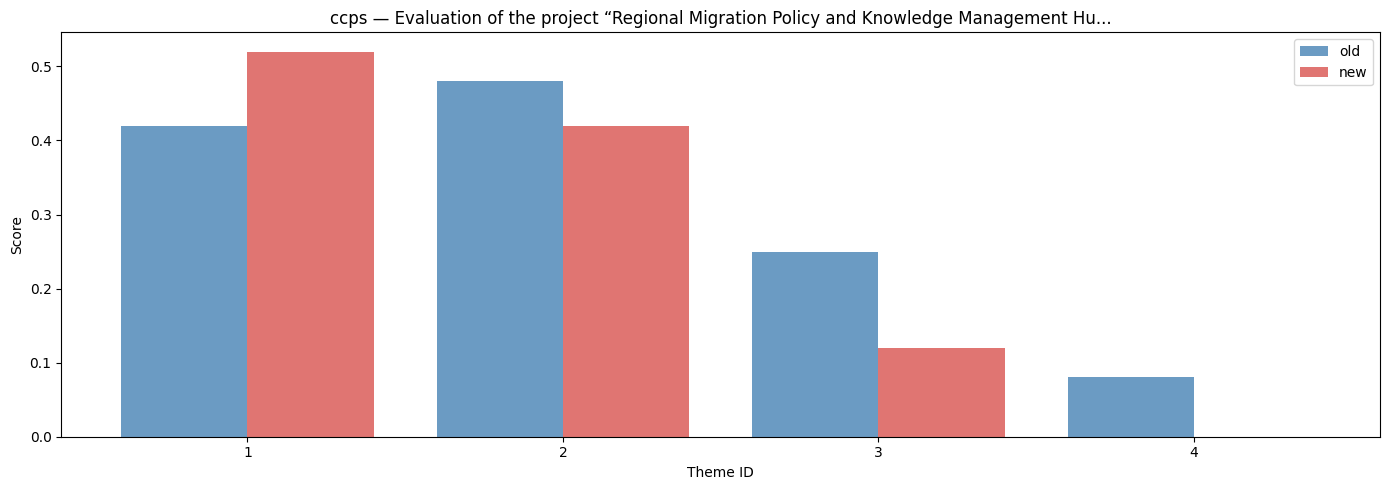

In [ ]:
for id_ in df_top_changed[df_top_changed.mapping_type == 'ccps'].eval_id:
    plot_scores_comparison(dfs, id_, 'ccps')